# Environment Setup
This cell installs the necessary library and checks if your GPU is active.

Note: Make sure you went to Edit > Notebook settings and selected T4 GPU

In [ ]:
# Install Ultralytics (YOLOv8)
%pip install ultralytics==8.3.0 --quiet

import ultralytics
from ultralytics import YOLO
import torch
import os
import glob
import yaml
from IPython.display import display, Image

# Verify environment
ultralytics.checks()
print(f"\nPyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Ultralytics version: {ultralytics.__version__}")
print("\n✅ Environment ready.")

Ultralytics 8.4.16 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 42.3/112.6 GB disk)

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
Ultralytics version: 8.4.16

✅ Environment ready.


# Dataset Download (automated, no manual upload)

In [ ]:
# ============================================================
# Option B: Download dataset zip from GitHub Release
# ============================================================
import zipfile

# Download from your GitHub release
!wget -q -O dataset.zip "https://github.com/Vagiadim/SiteAI-equipment-tracker-/releases/download/v1.0/dataset.zip"

# Extract
with zipfile.ZipFile('dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("\n✅ Dataset downloaded from GitHub and extracted.")


✅ Dataset downloaded from GitHub and extracted.


# Fix Dataset Paths (YAML)
Roboflow gives us a data.yaml file, but it doesn't know we are on Google Colab. We need to tell it exactly where the images are.

In [ ]:
import yaml

yaml_path = '/content/dataset/data.yaml'

with open(yaml_path, 'r') as f:
    config = yaml.safe_load(f)

# Update paths for Colab
config['train'] = '/content/dataset/train/images'
config['val']   = '/content/dataset/valid/images'
config['test']  = '/content/dataset/test/images'

with open(yaml_path, 'w') as f:
    yaml.dump(config, f)

# Display the config
print("Dataset configuration:")
print(f"  Train: {config['train']}")
print(f"  Val:   {config['val']}")
print(f"  Test:  {config['test']}")
print(f"  Classes ({config['nc']}): {config['names']}")

# Count images per split
for split in ['train', 'val', 'test']:
    path = config.get(split, '')
    if os.path.exists(path):
        count = len([f for f in os.listdir(path) if f.endswith(('.jpg','.jpeg','.png'))])
        print(f"  {split}: {count} images")

print("\n✅ Paths configured.")

Dataset configuration:
  Train: /content/dataset/train/images
  Val:   /content/dataset/valid/images
  Test:  /content/dataset/test/images
  Classes (7): ['boom_lift', 'dump_truck', 'excavator', 'loader', 'mixer_truck', 'roller', 'tower_crane']
  train: 1391 images
  val: 59 images
  test: 58 images

✅ Paths configured.


In [ ]:
import yaml
import os

# Define the path to the yaml file inside the extracted folder
yaml_path = '/content/dataset/data.yaml'

if os.path.exists(yaml_path):
    with open(yaml_path, 'r') as f:
        config = yaml.safe_load(f)

    # Overwrite the paths to ensure they are absolute for Colab's environment
    config['train'] = '/content/dataset/train/images'
    config['val'] = '/content/dataset/valid/images'
    config['test'] = '/content/dataset/test/images'

    # Save the corrected version back to the file
    with open(yaml_path, 'w') as f:
        yaml.dump(config, f)

    print("✅ data.yaml paths verified and updated for Colab!")
else:
    print("❌ Error: data.yaml not found. Check if your dataset extracted correctly.")

✅ data.yaml paths verified and updated for Colab!


# Train YOLOv8n
Now we train. This uses the Nano model and RAM caching for speed.

In [ ]:
from ultralytics import YOLO

# Load pre-trained YOLOv8 Nano
model = YOLO('yolov8n.pt')

# Train
results = model.train(
    data='/content/dataset/data.yaml',
    epochs=30,
    imgsz=640,
    batch=-1,       # Auto batch size
    cache=True,     # Cache images in RAM for speed
    name='siteai_equipment',
    patience=10,    # Early stopping if no improvement for 10 epochs
    save=True,      # Save checkpoints
    plots=True      # Generate training plots
)

print("\n✅ Training complete!")

Ultralytics 8.4.16 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=siteai_equipment3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, pers

# Evaluate Model & Print Metrics

In [ ]:
from ultralytics import YOLO

# Load the best weights from training
best_weights = '/content/runs/detect/siteai_equipment2/weights/best.pt'
model = YOLO(best_weights)

# Run validation
metrics = model.val(data='/content/dataset/data.yaml')

# Print results summary
print("\n" + "="*50)
print("         MODEL EVALUATION RESULTS")
print("="*50)
print(f"  Precision:    {metrics.box.mp:.3f}")
print(f"  Recall:       {metrics.box.mr:.3f}")
print(f"  mAP@50:       {metrics.box.map50:.3f}")
print(f"  mAP@50-95:    {metrics.box.map:.3f}")
print("="*50)

# Per-class results
print("\nPer-class mAP@50:")
class_names = model.names
for i, ap in enumerate(metrics.box.ap50):
    name = class_names[i] if i in class_names else f"class_{i}"
    bar = '█' * int(ap * 30)
    print(f"  {name:<15} {ap:.1%}  {bar}")

print("\n✅ Evaluation complete.")

Ultralytics 8.4.16 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1654.5±728.0 MB/s, size: 61.3 KB)
val: Scanning /content/dataset/valid/labels.cache... 59 images, 7 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 59/59 2.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.9it/s 2.1s
                   all         59        184      0.683      0.542      0.606      0.468
             boom_lift          2          5      0.736      0.567      0.497      0.447
            dump_truck         11         49      0.794      0.158      0.406      0.217
             excavator         16         52      0.718      0.635      0.649      0.404
                loader          4          6      0.464        0.5      0.689      0.575
           mixer_truck         10         23      0.923

# Display Training Curves

📊 Training Curves & Plots

--- Training Plots from /content/runs/detect/siteai_equipment3/ ---
  results.png


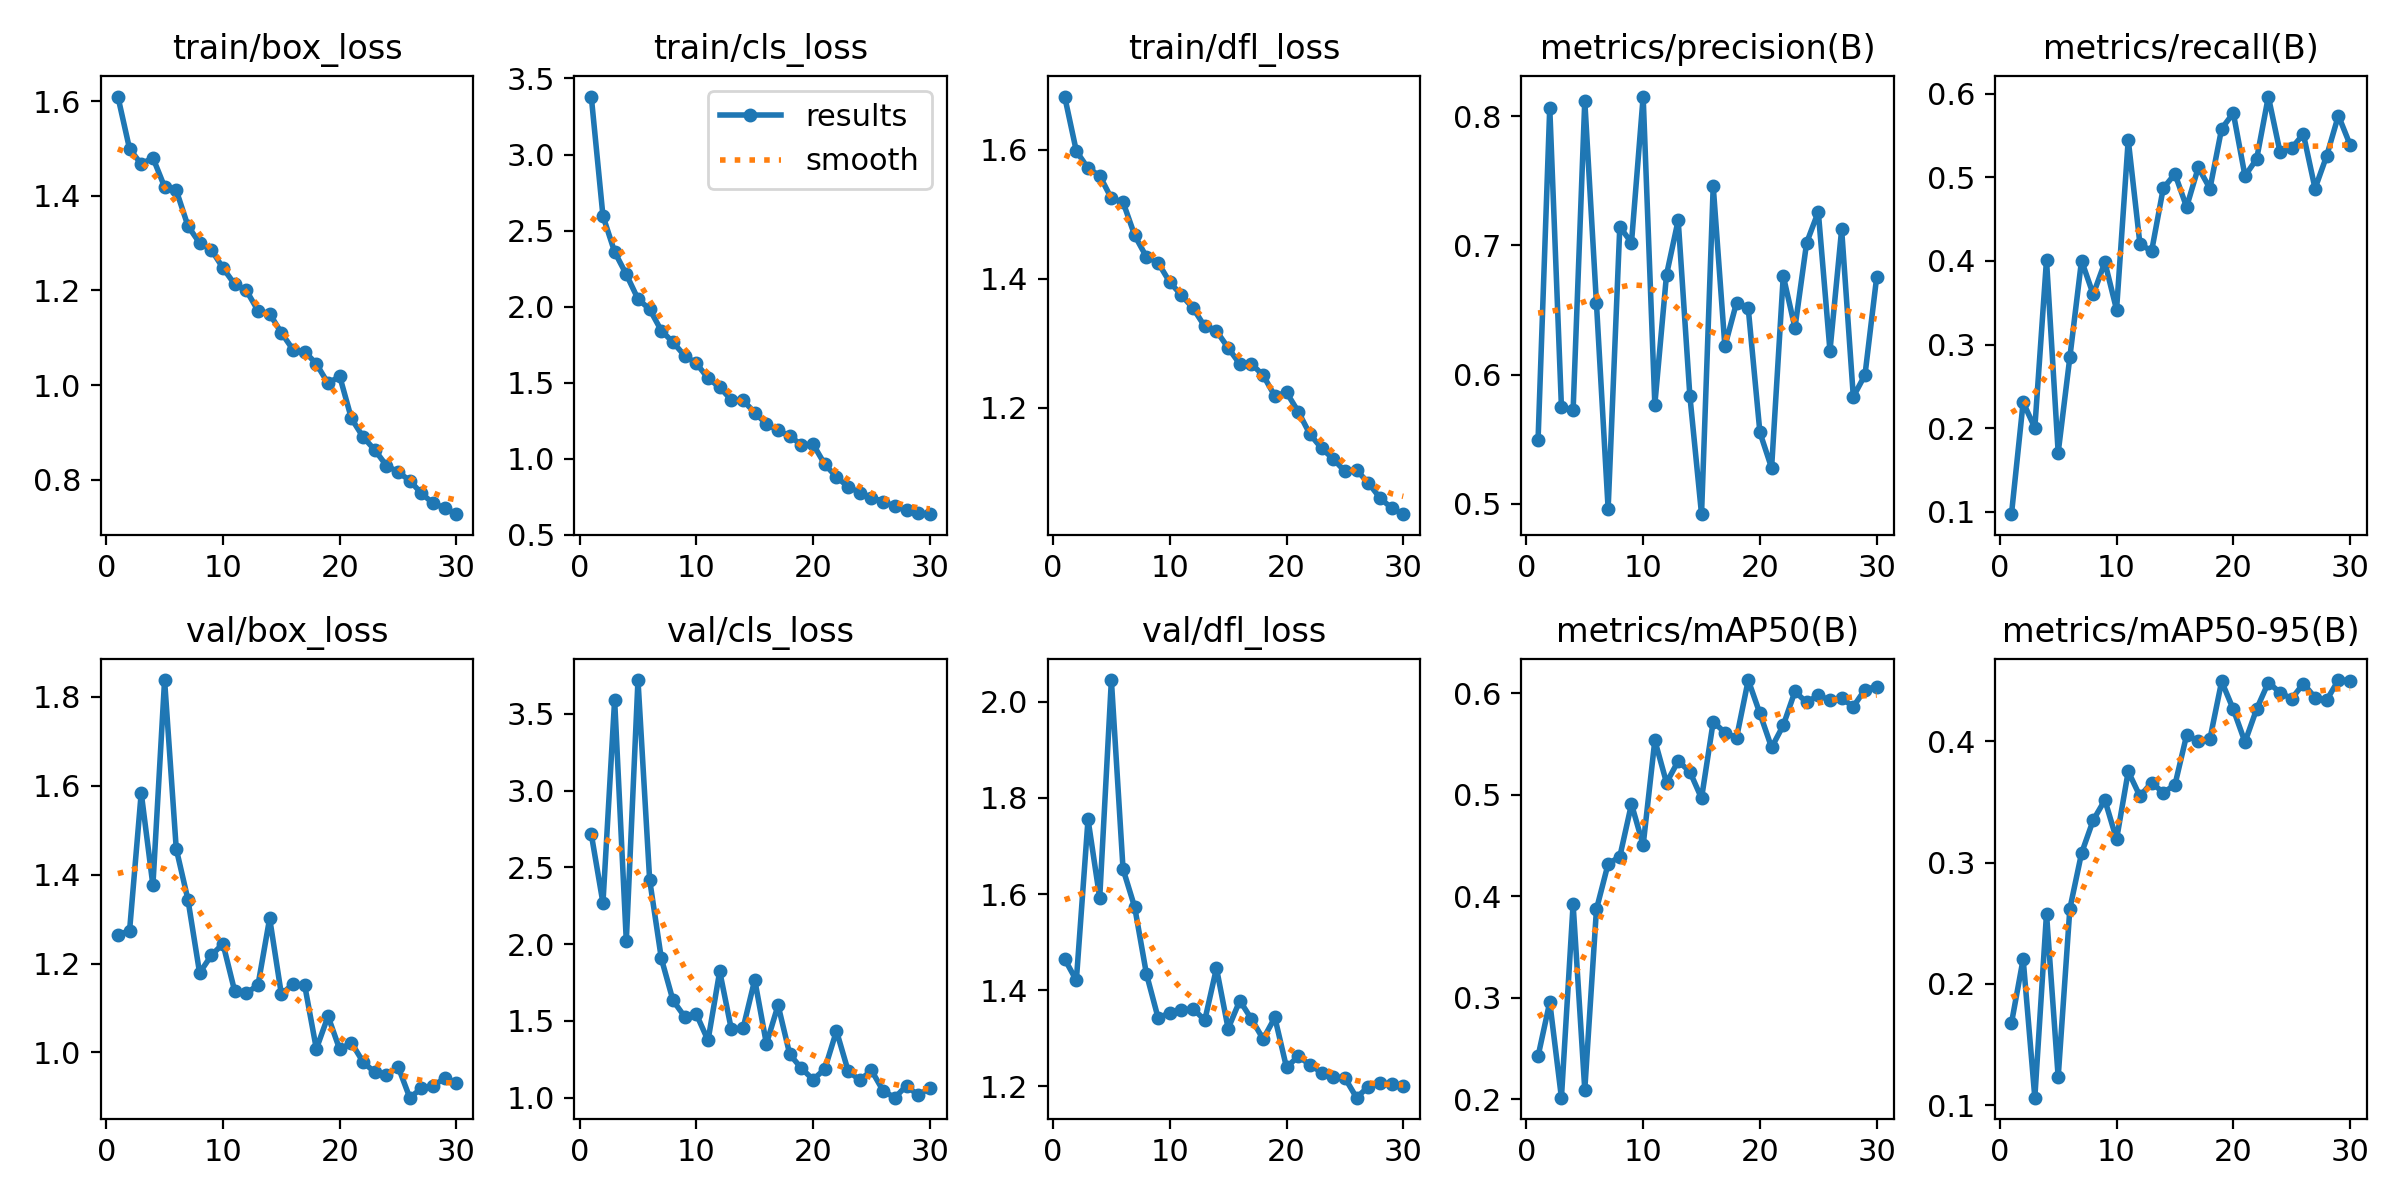


  confusion_matrix.png


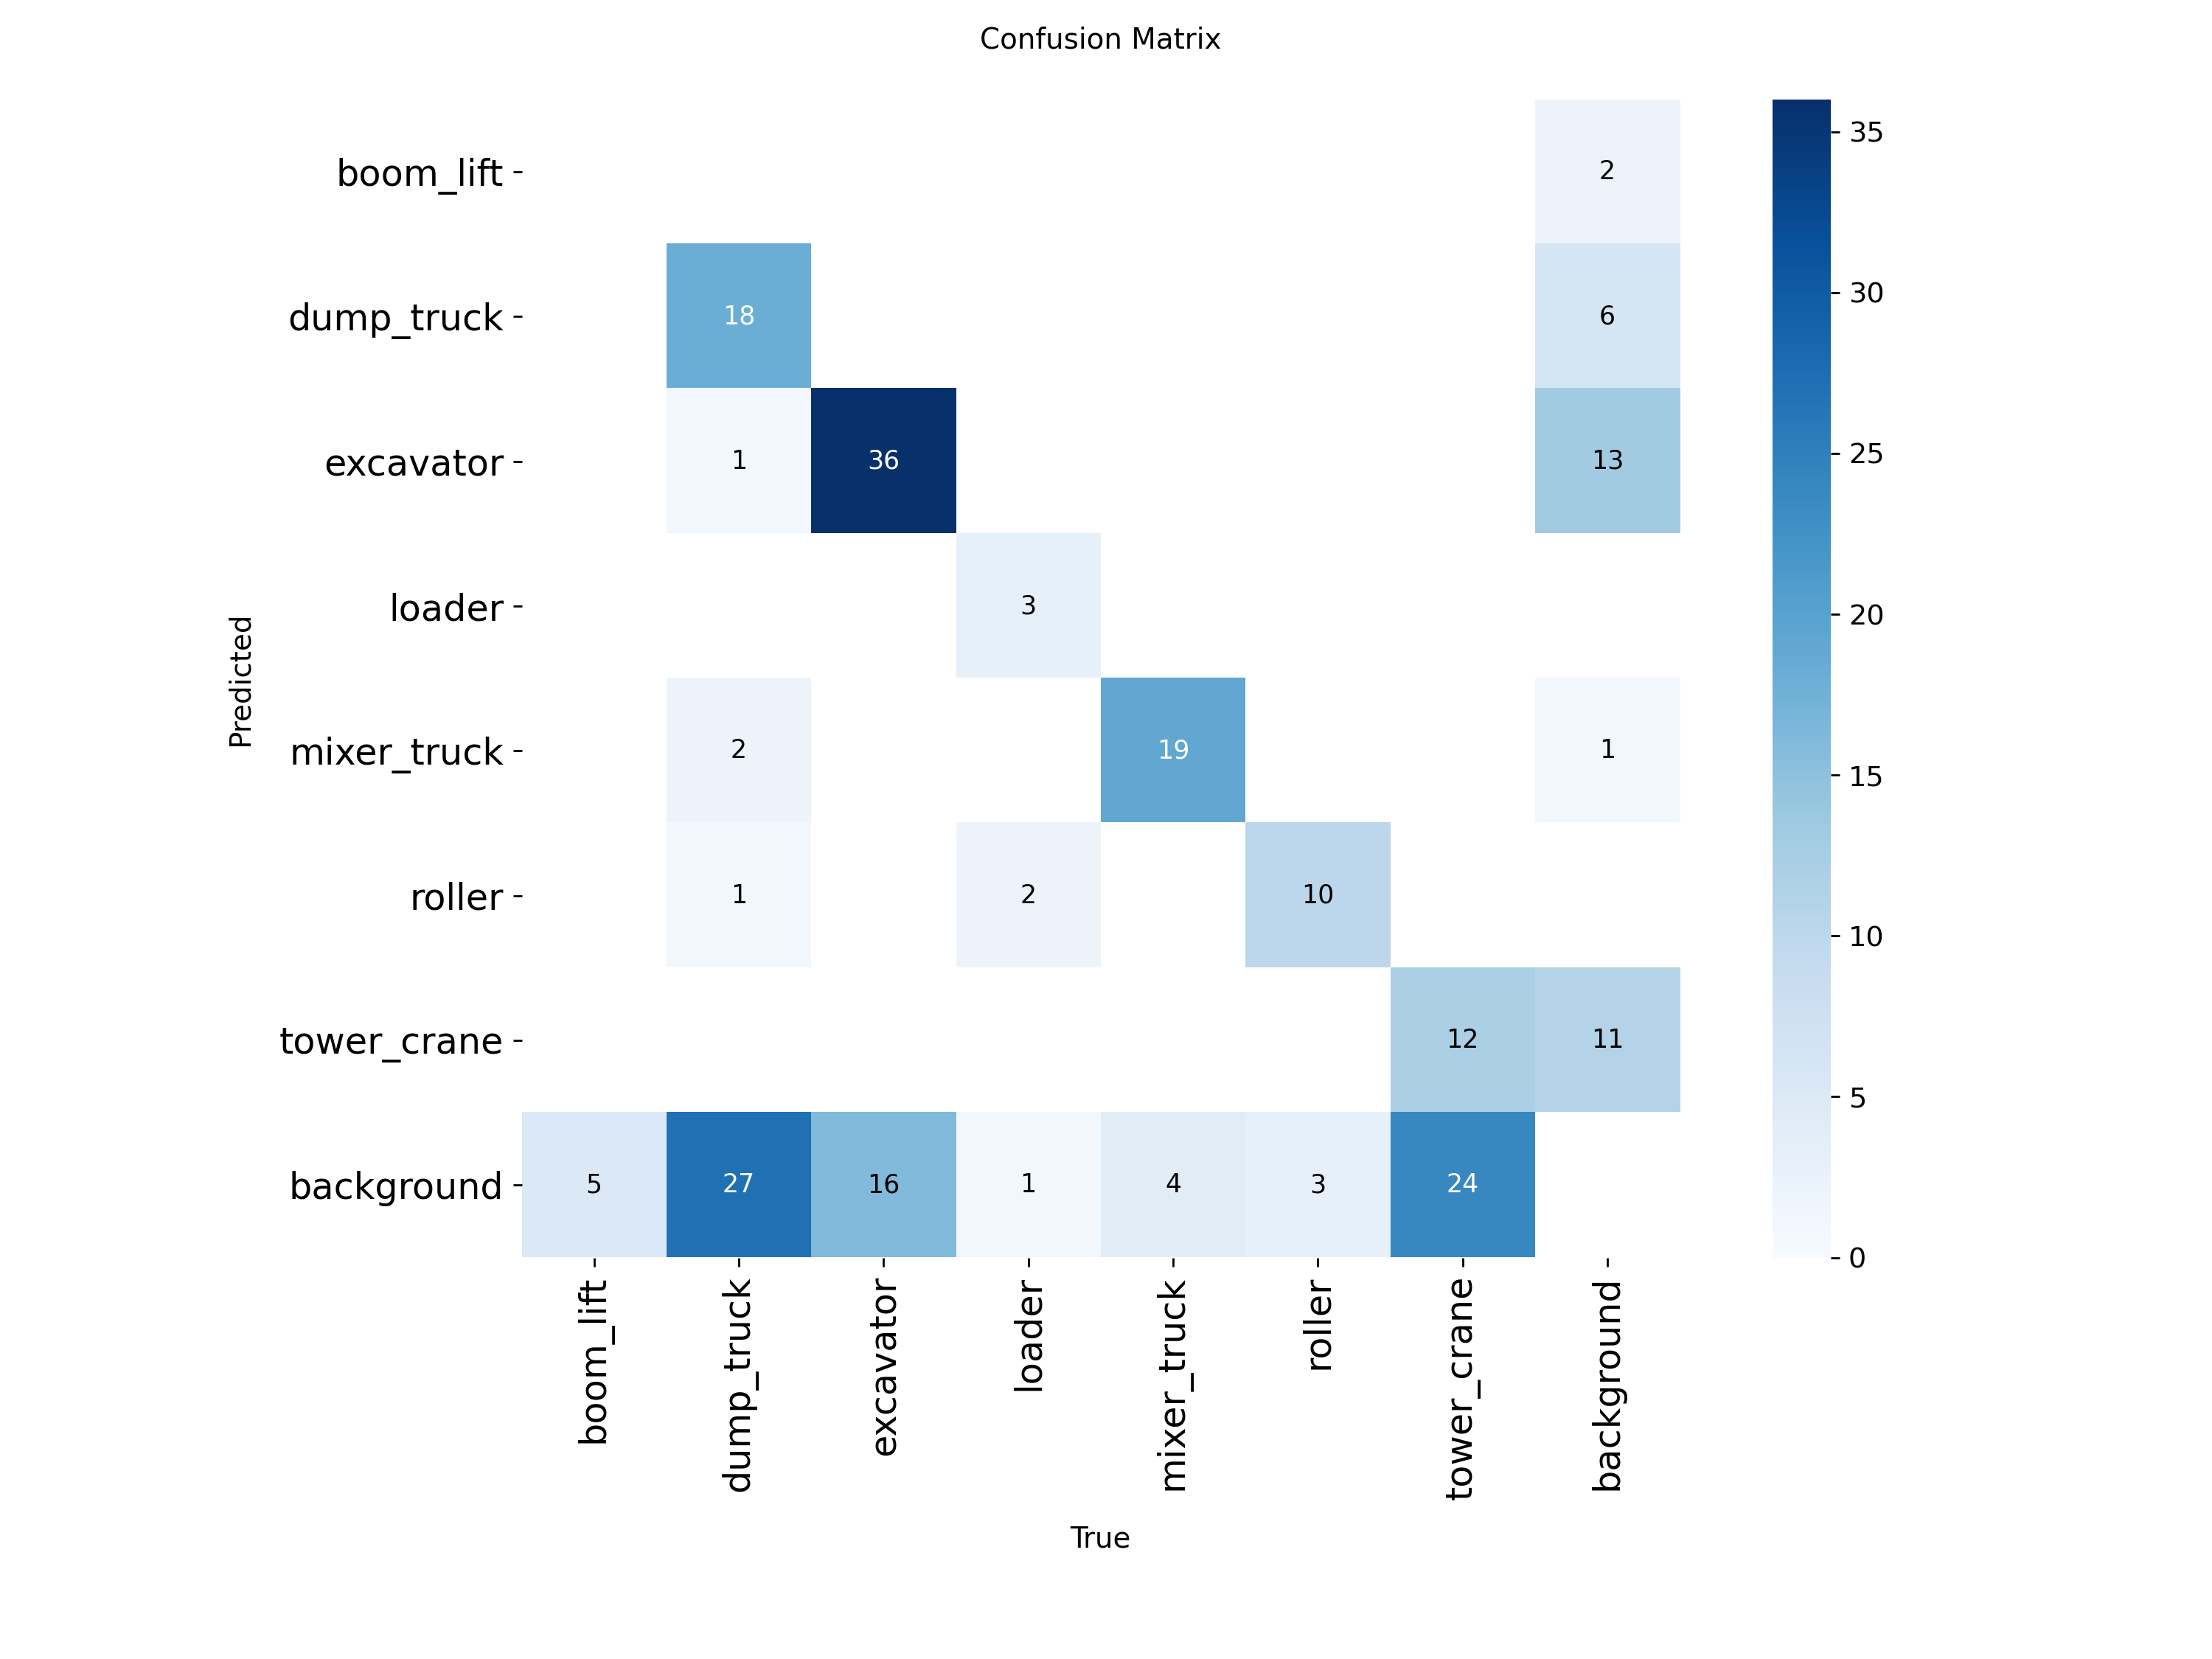


  confusion_matrix_normalized.png


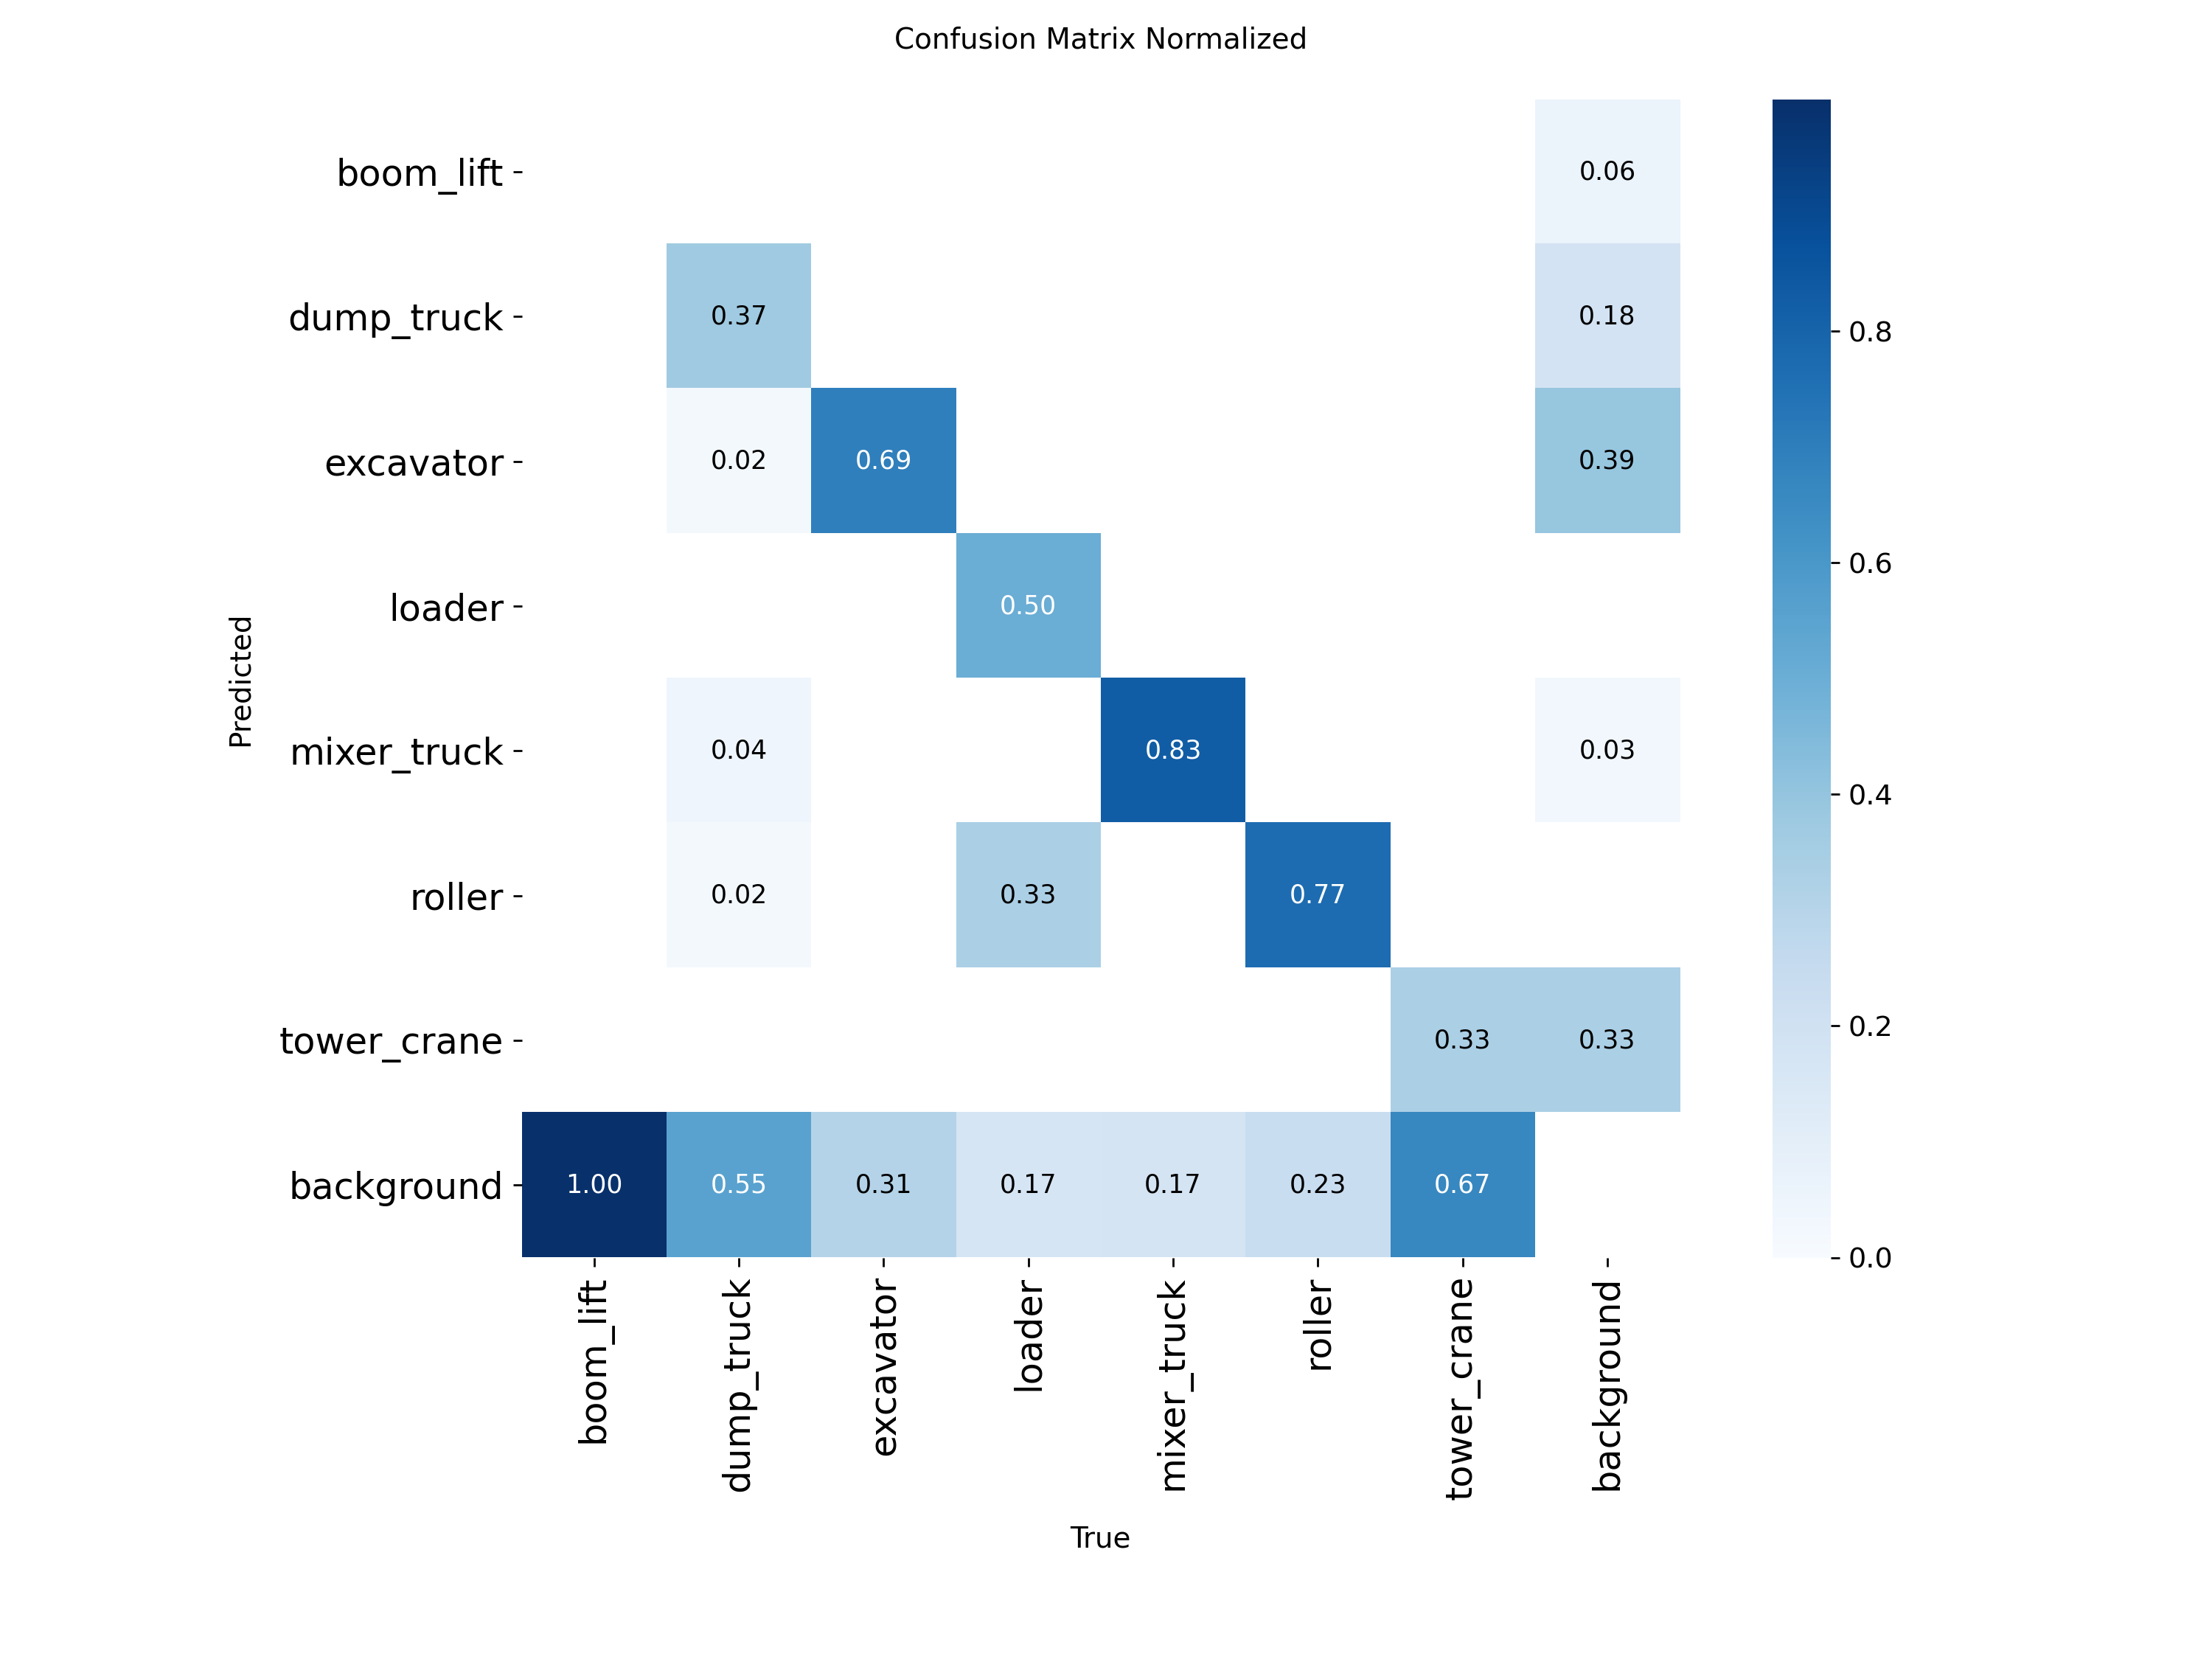



--- Validation Plots from /content/runs/detect/val2/ ---
  BoxP_curve.png


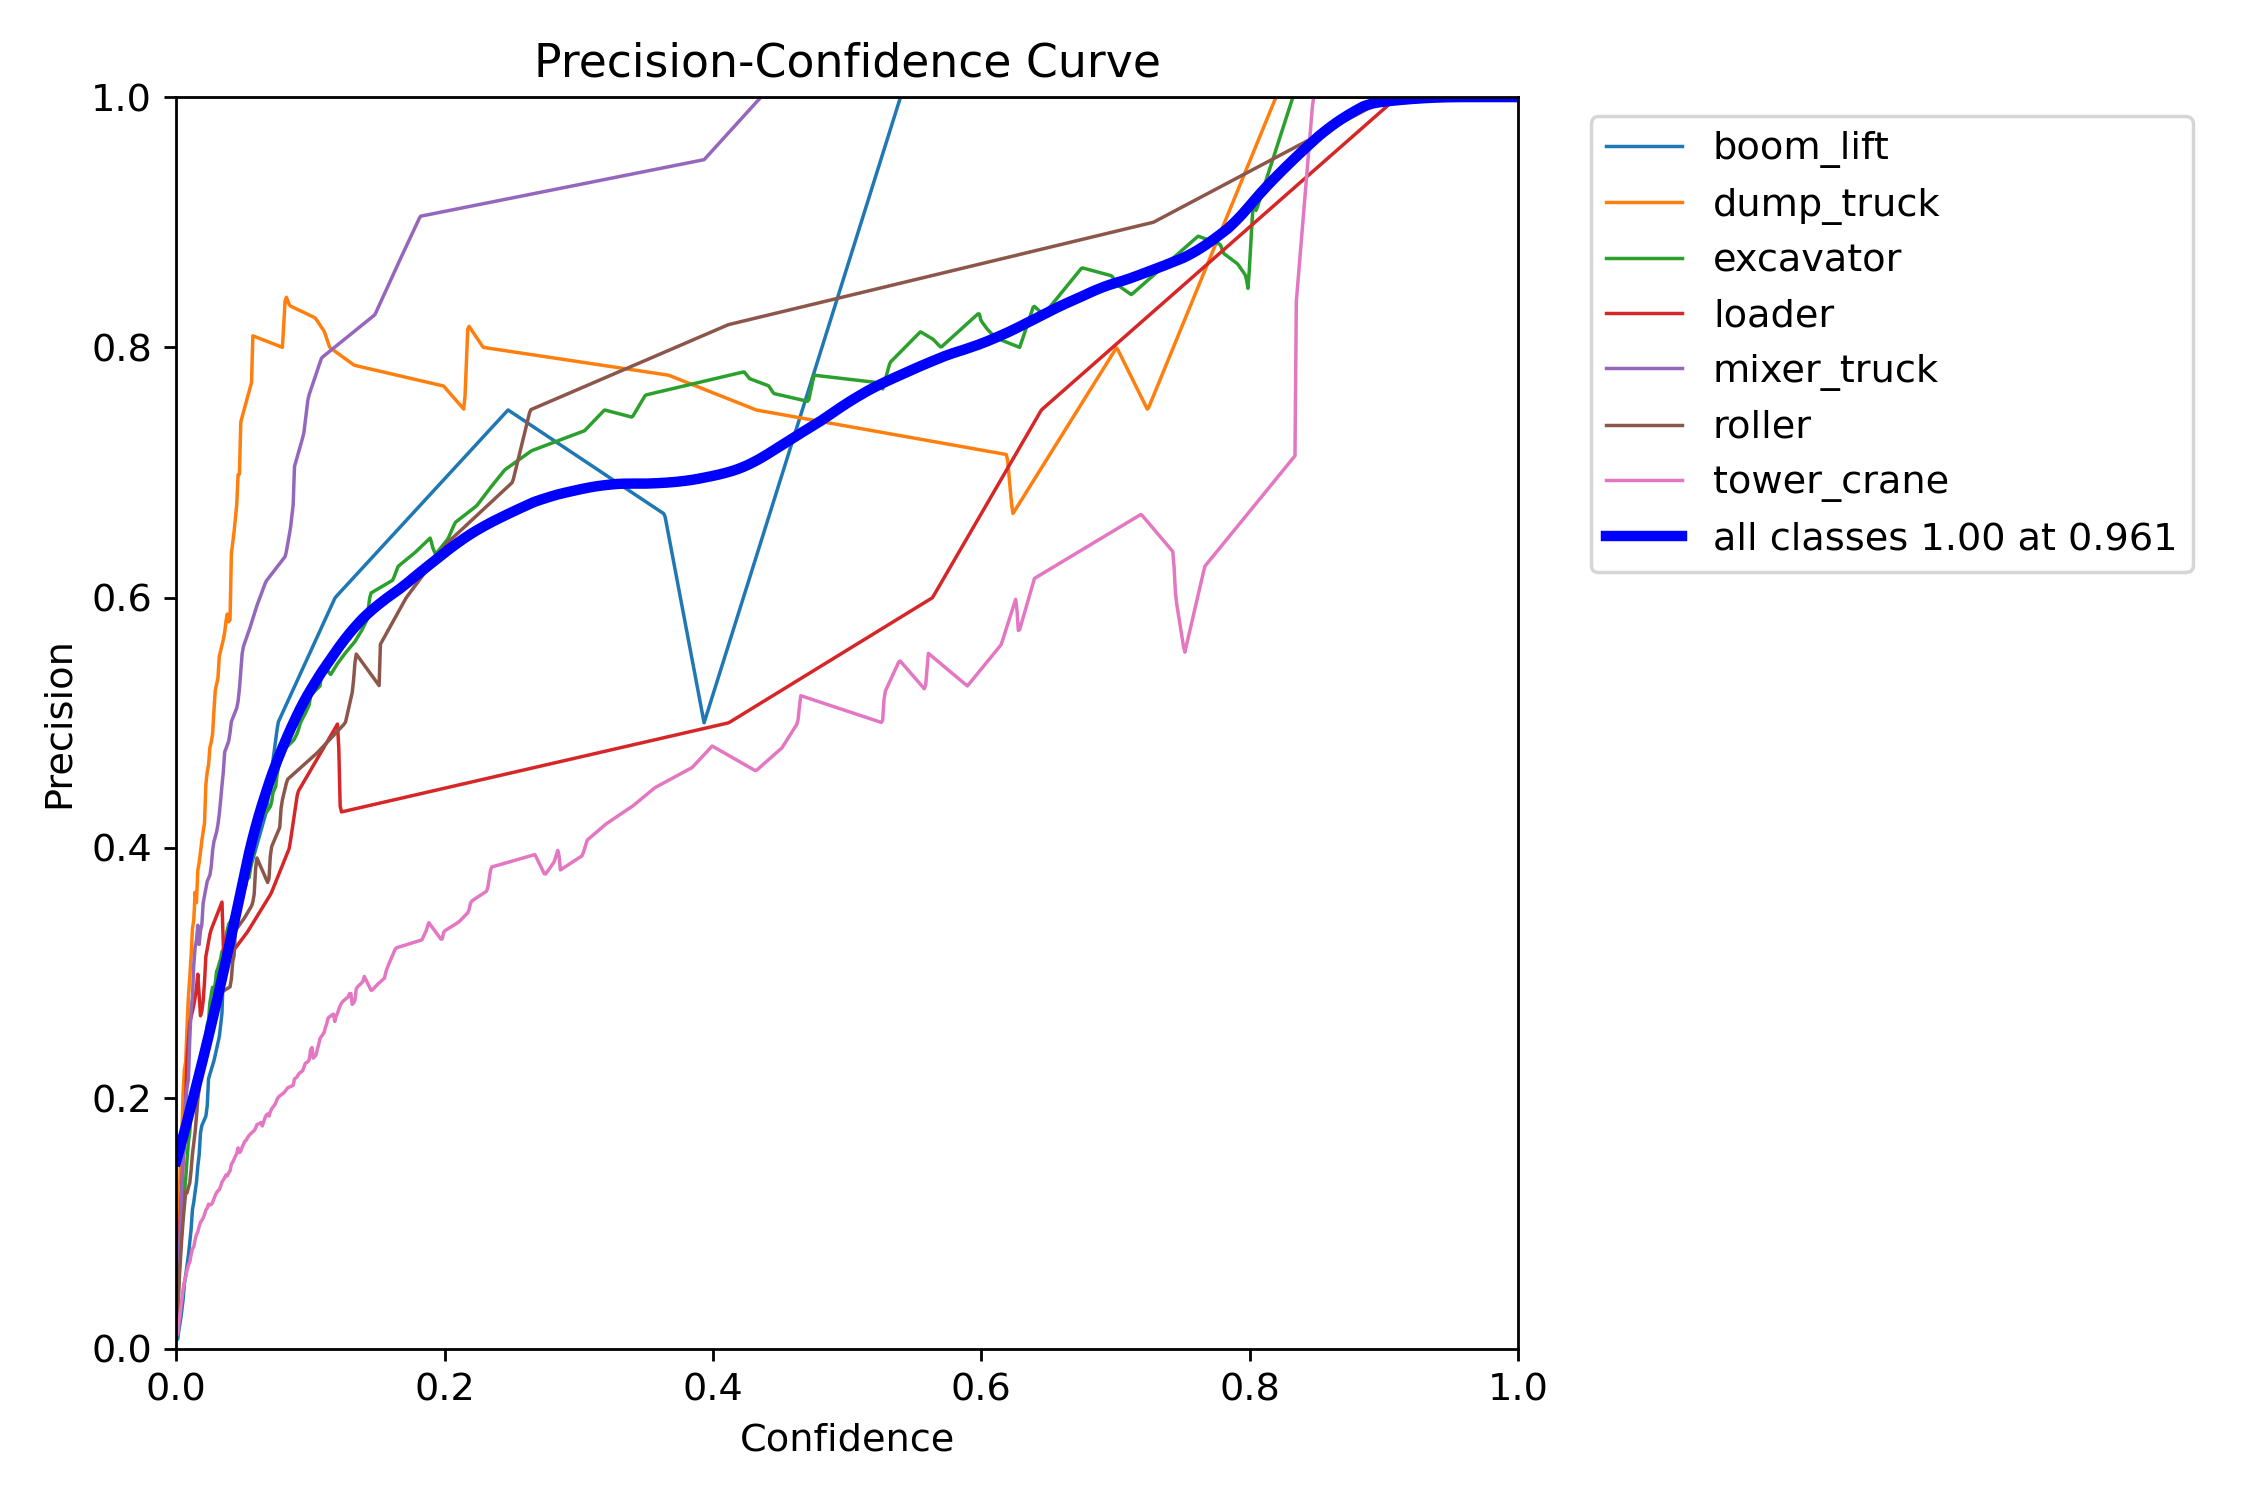


  BoxR_curve.png


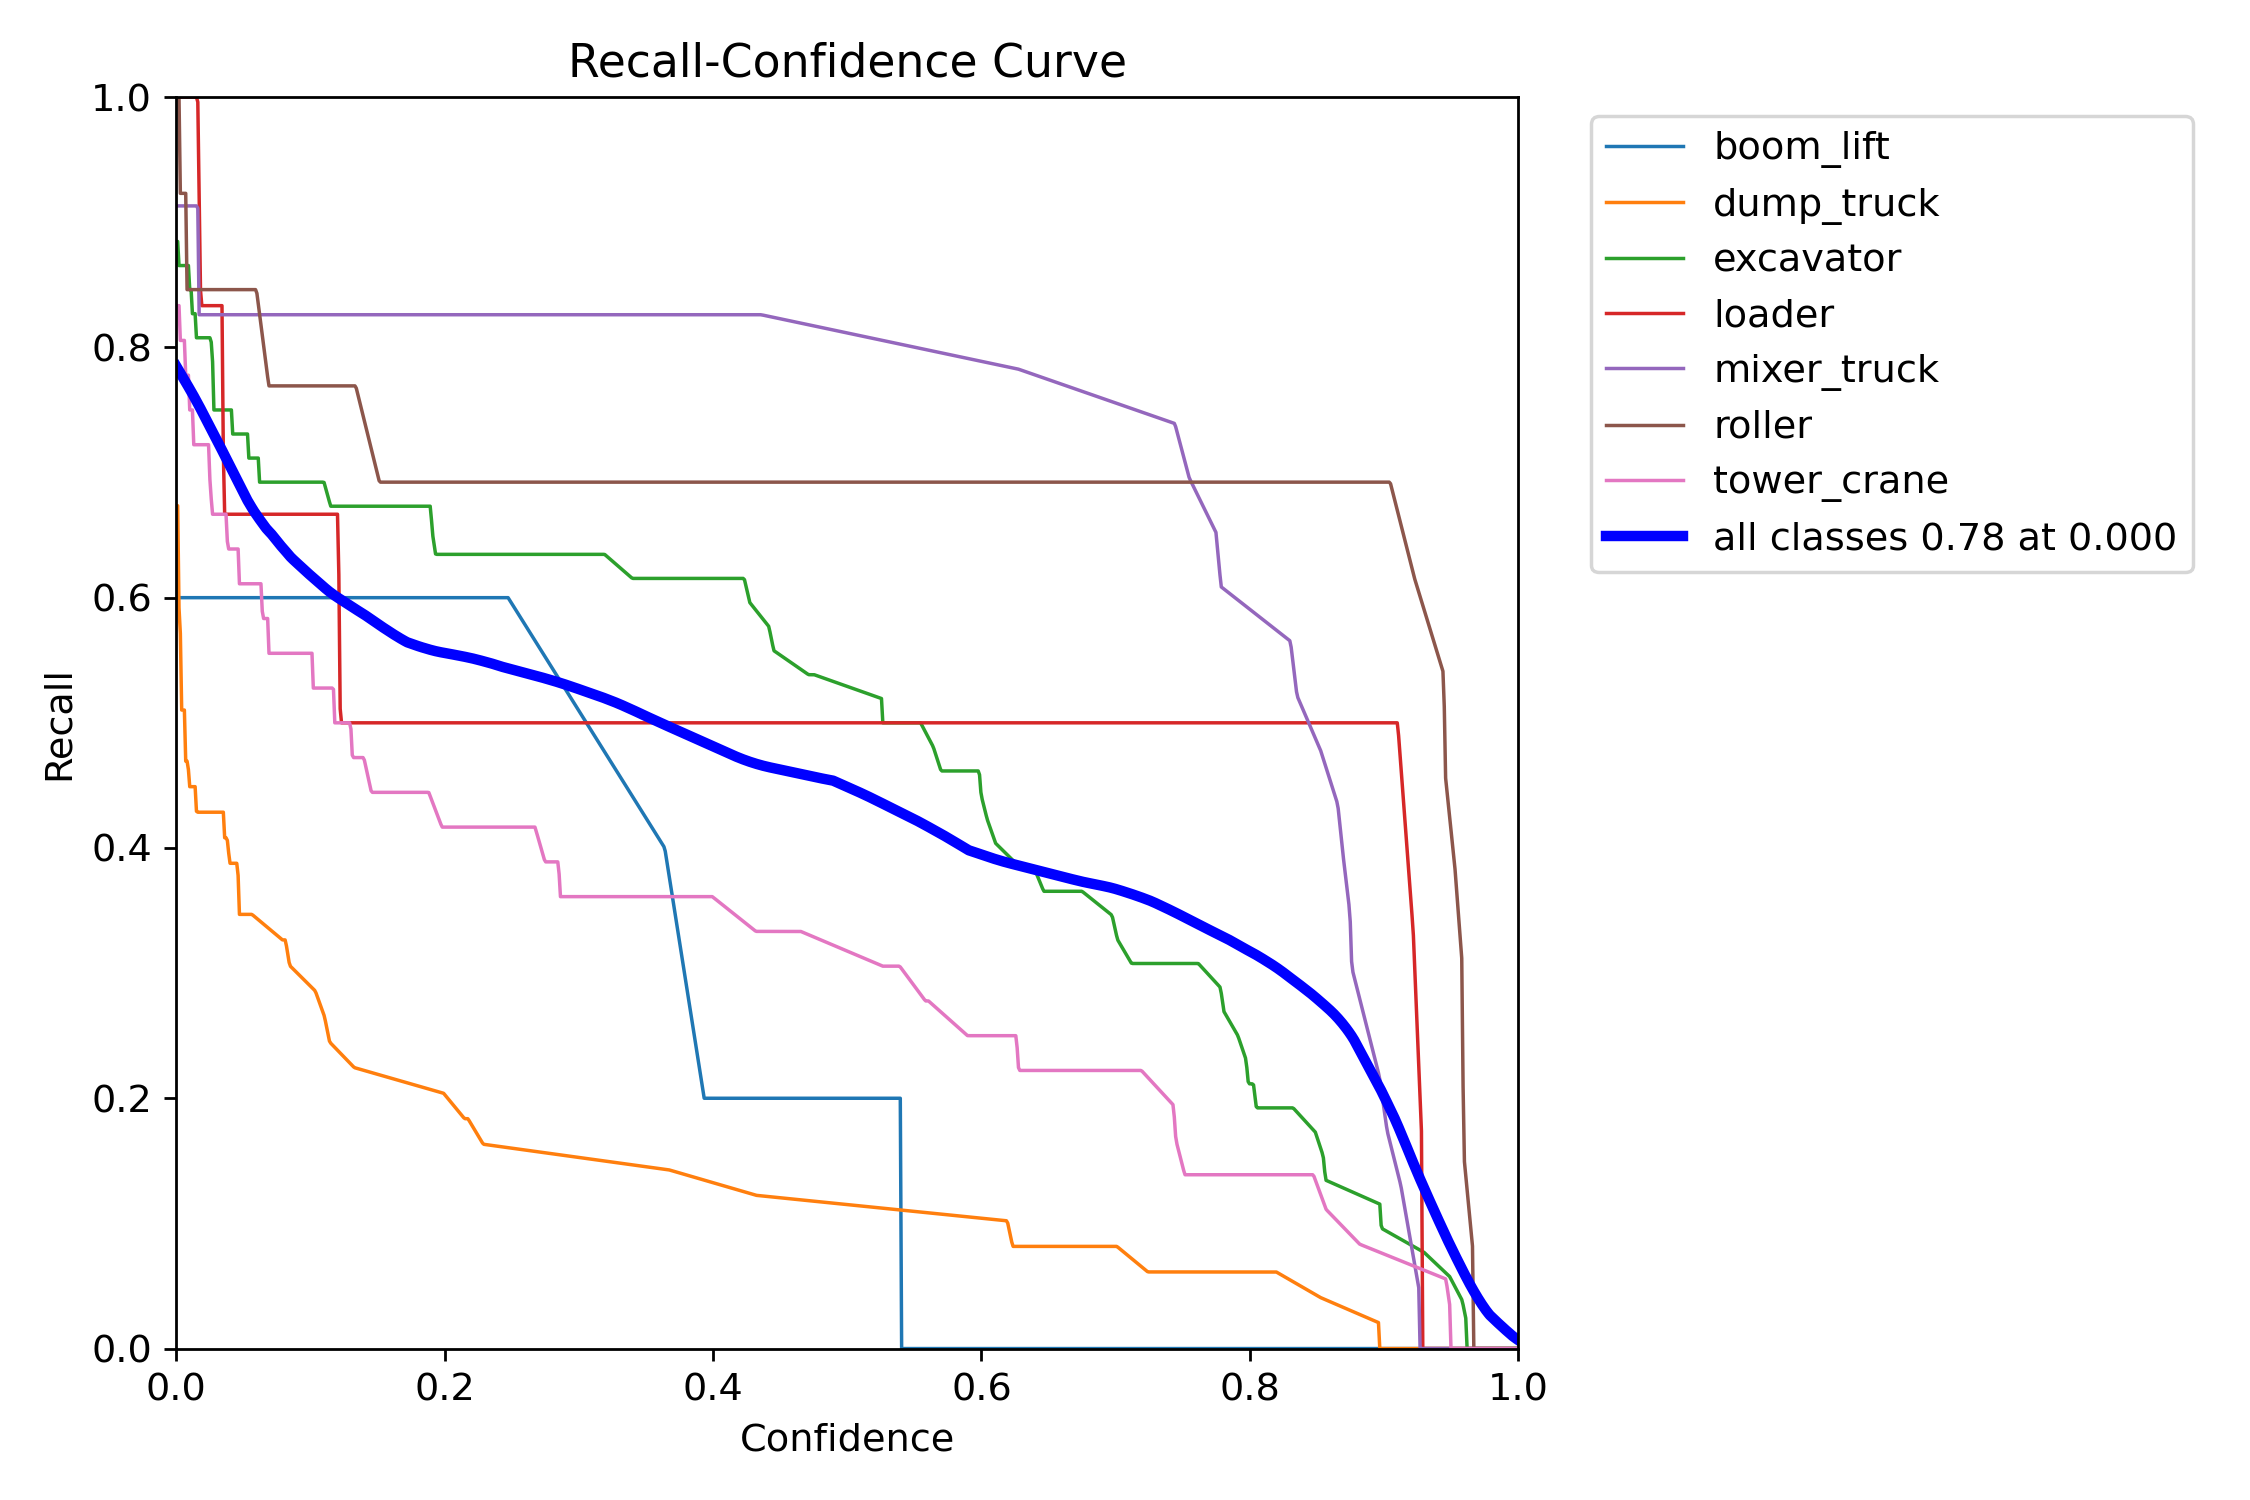


  BoxF1_curve.png


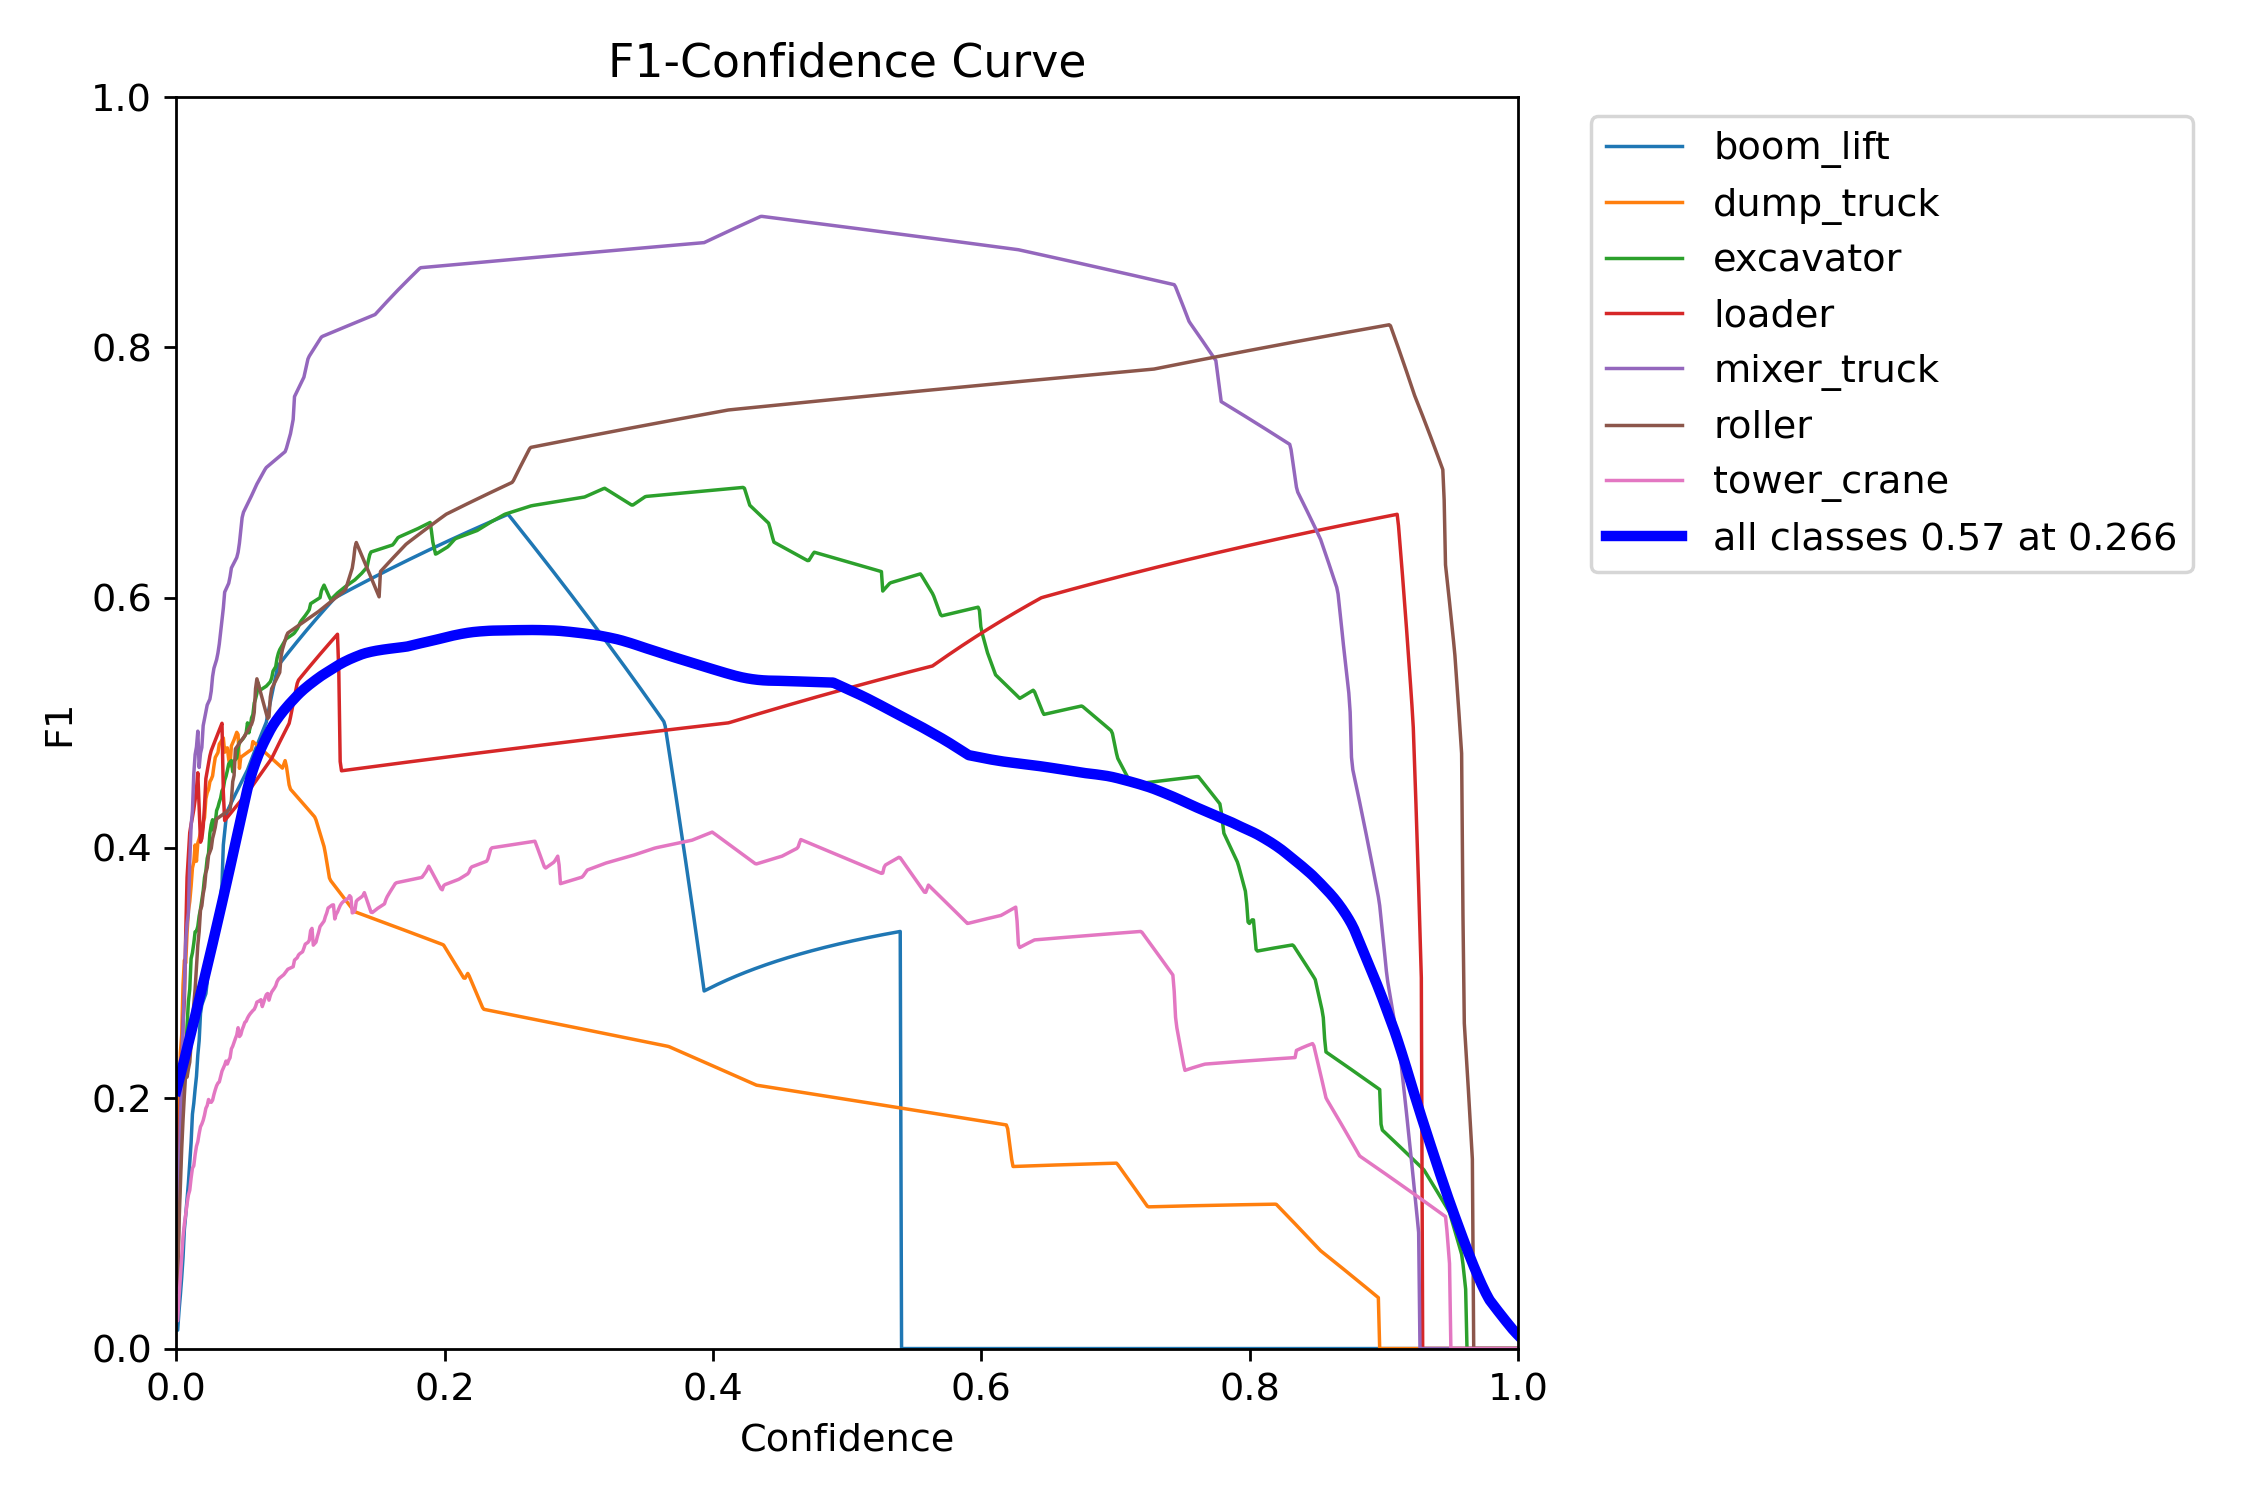


  BoxPR_curve.png


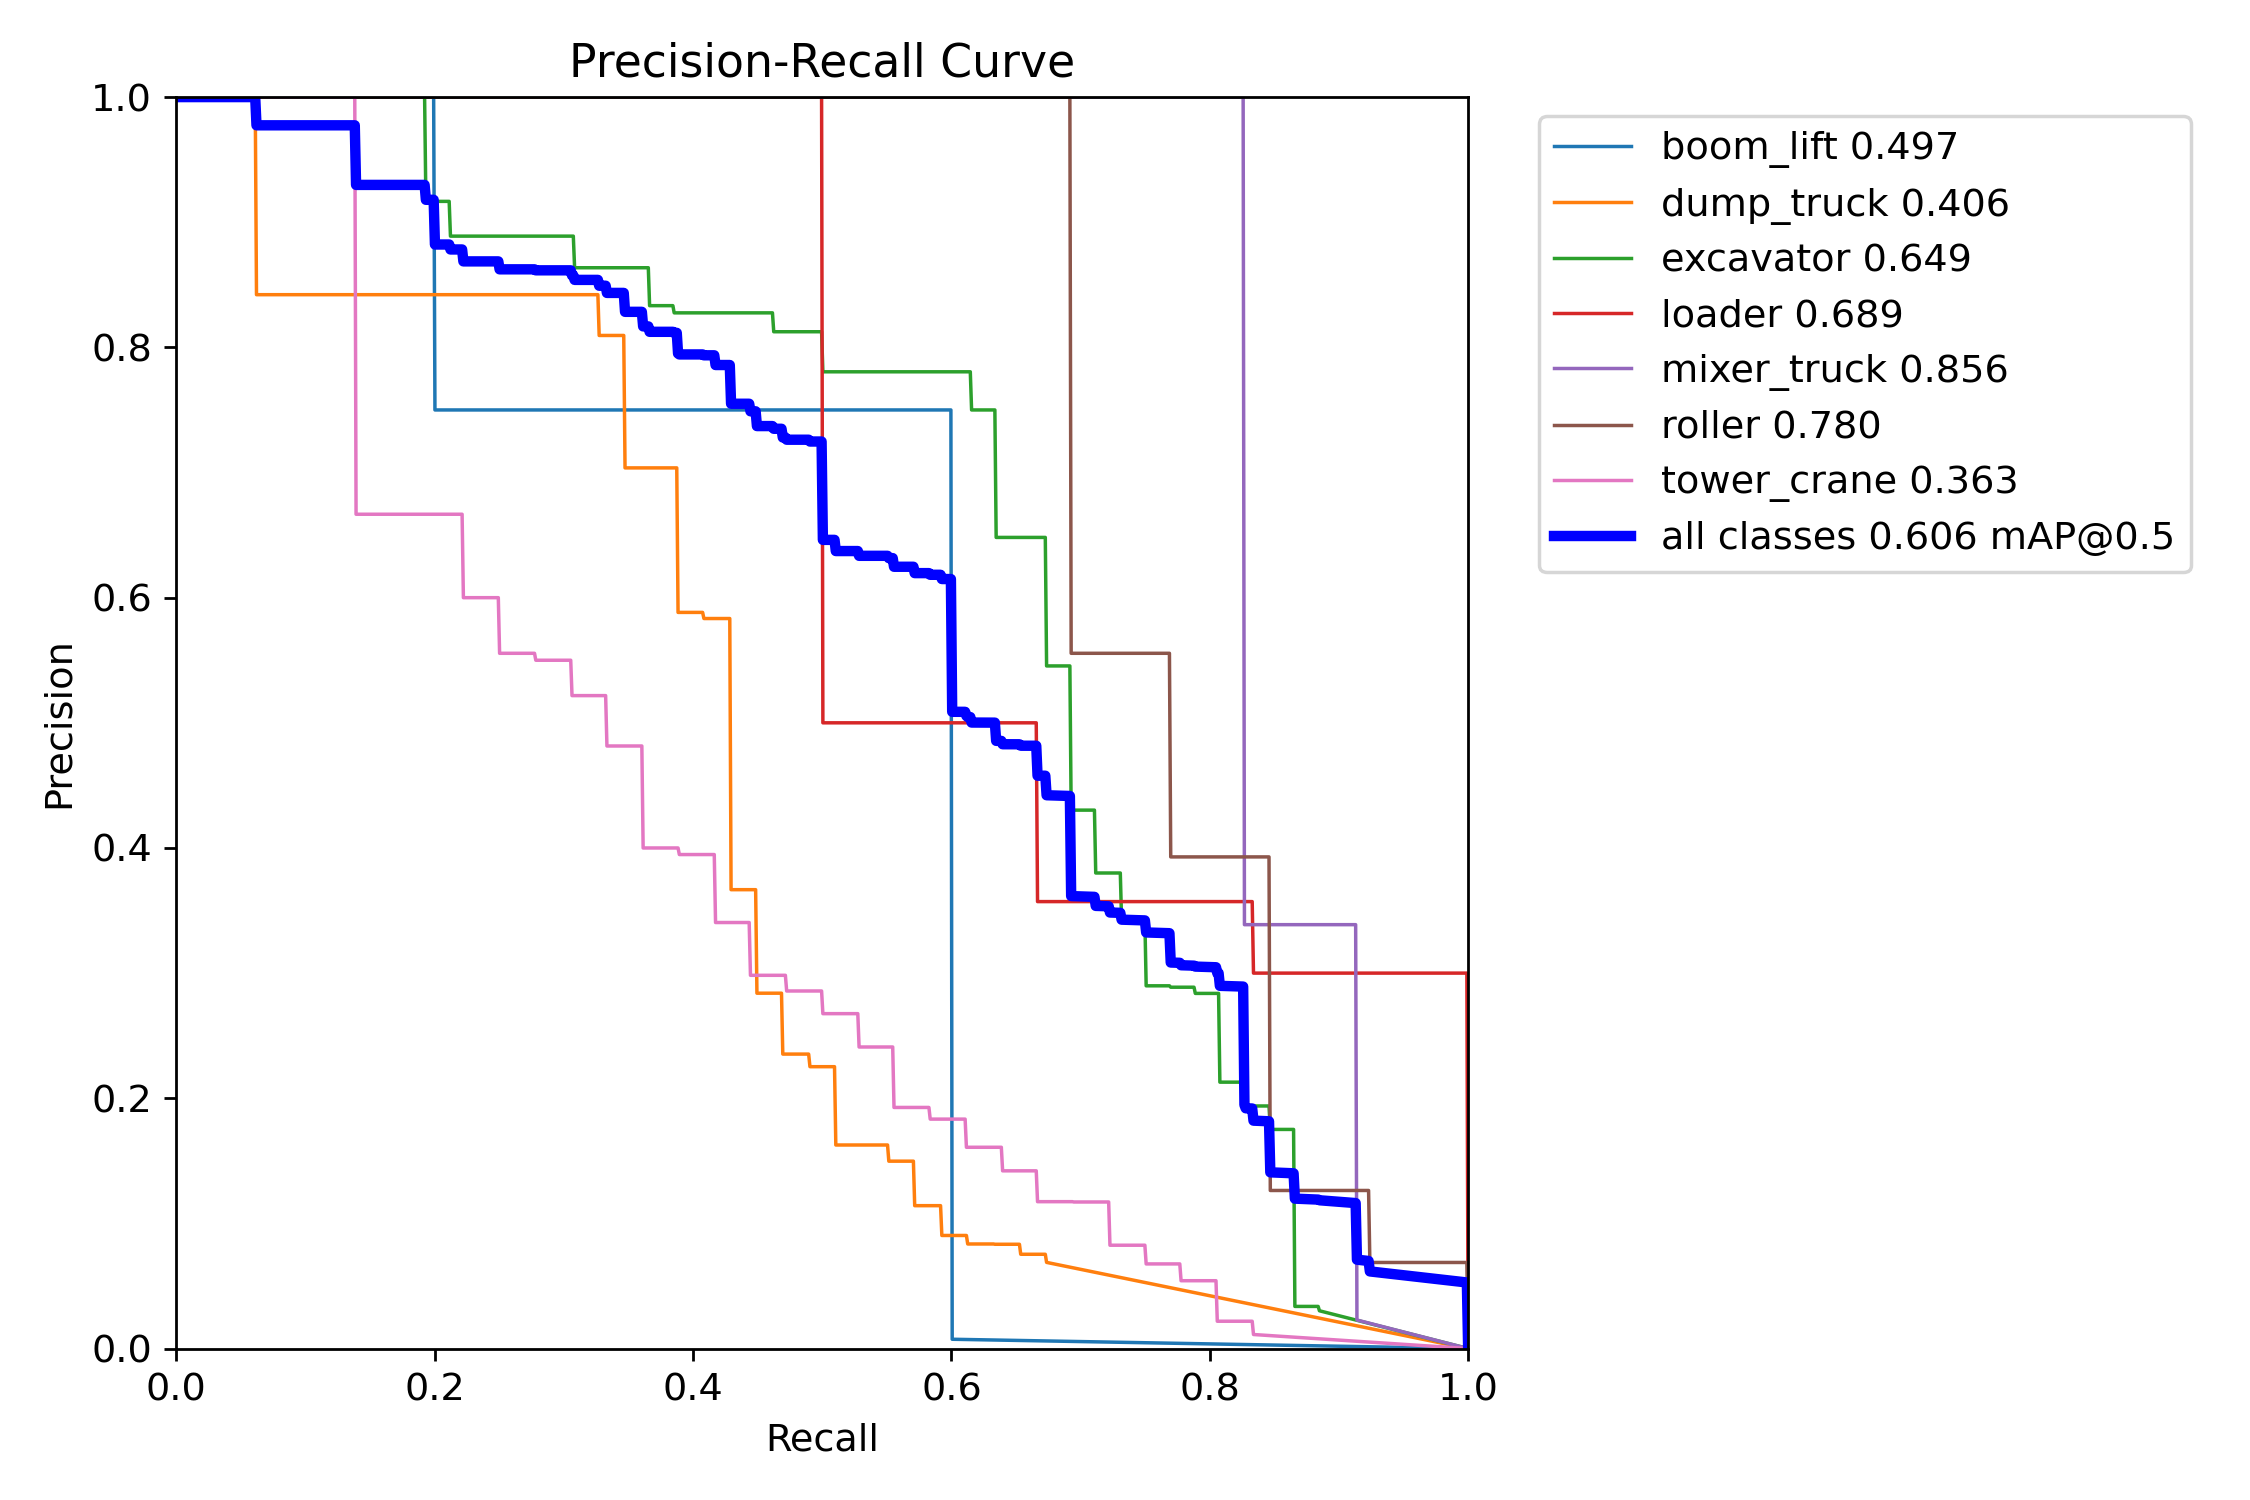



✅ Displayed 7 training and validation plots.


In [ ]:
from IPython.display import display, Image
import os

training_plots_dir = '/content/runs/detect/siteai_equipment3/'
validation_plots_dir = '/content/runs/detect/val2/' # This is where model.val() saves its plots

# Plots expected from training
train_plot_files = [
    'results.png',
    'confusion_matrix.png',
    'confusion_matrix_normalized.png'
]

# Plots expected from validation
val_plot_files = [
    'BoxP_curve.png', # Corrected filename
    'BoxR_curve.png', # Corrected filename
    'BoxF1_curve.png', # Corrected filename
    'BoxPR_curve.png'  # Corrected filename
]

print("📊 Training Curves & Plots\n")
found = 0

# Display training plots
print(f"--- Training Plots from {training_plots_dir} ---")
for plot in train_plot_files:
    path = os.path.join(training_plots_dir, plot)
    if os.path.exists(path):
        print(f"  {plot}")
        display(Image(filename=path, width=700))
        print()
        found += 1

# Display validation plots
print(f"\n--- Validation Plots from {validation_plots_dir} ---")
for plot in val_plot_files:
    path = os.path.join(validation_plots_dir, plot)
    if os.path.exists(path):
        print(f"  {plot}")
        display(Image(filename=path, width=700))
        print()
        found += 1

print(f"\n✅ Displayed {found} training and validation plots.")

In [ ]:
import os

validation_plots_dir = '/content/runs/detect/val2/'

print(f"Contents of {validation_plots_dir}:")
if os.path.exists(validation_plots_dir):
    for item in os.listdir(validation_plots_dir):
        print(f"- {item}")
else:
    print("Directory does not exist.")

Contents of /content/runs/detect/val2/:
- BoxP_curve.png
- val_batch0_pred.jpg
- BoxF1_curve.png
- BoxPR_curve.png
- val_batch2_pred.jpg
- BoxR_curve.png
- val_batch0_labels.jpg
- confusion_matrix_normalized.png
- val_batch2_labels.jpg
- val_batch1_pred.jpg
- val_batch1_labels.jpg
- confusion_matrix.png


# Validation Predictions (10 examples)

Running predictions on 10 validation images...


0: 640x640 1 boom_lift, 3 dump_trucks, 3 excavators, 5.0ms
1: 640x640 2 excavators, 5.0ms
2: 640x640 2 tower_cranes, 5.0ms
3: 640x640 1 dump_truck, 1 excavator, 1 roller, 5.0ms
4: 640x640 4 dump_trucks, 5 excavators, 5.0ms
5: 640x640 2 excavators, 5.0ms
6: 640x640 3 excavators, 5.0ms
7: 640x640 4 excavators, 5.0ms
8: 640x640 6 excavators, 5.0ms
9: 640x640 1 dump_truck, 5 excavators, 5.0ms
Speed: 1.8ms preprocess, 5.0ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/val_predictions3
📸 image0.jpg


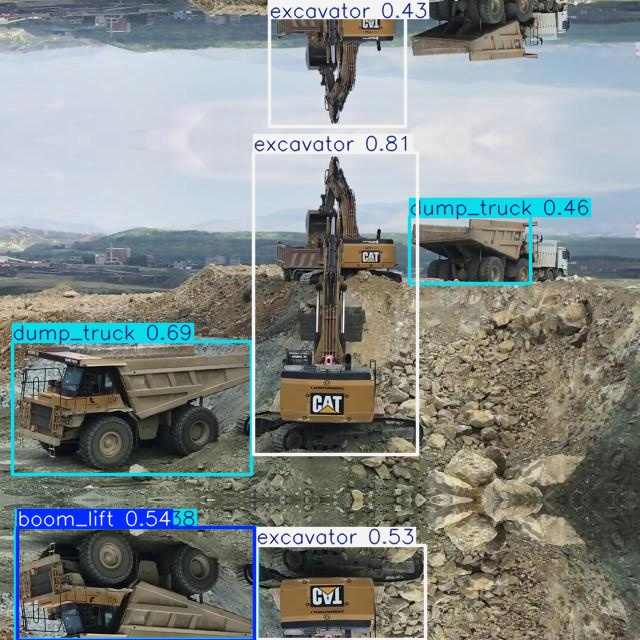


📸 image1.jpg


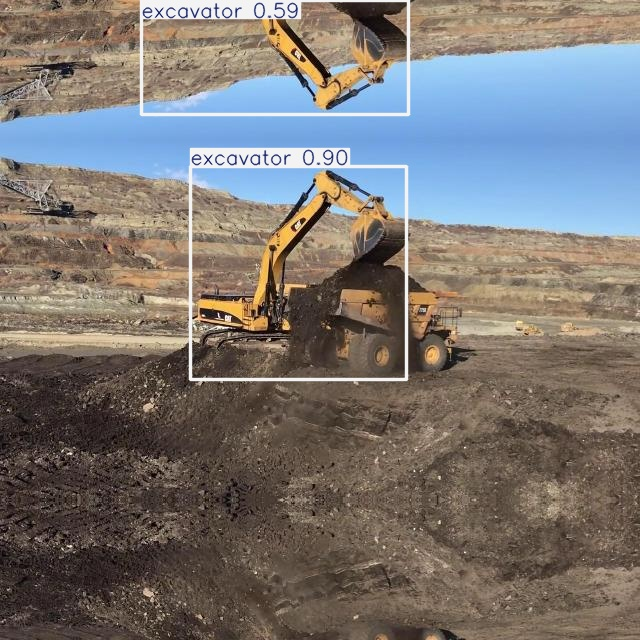


📸 image2.jpg


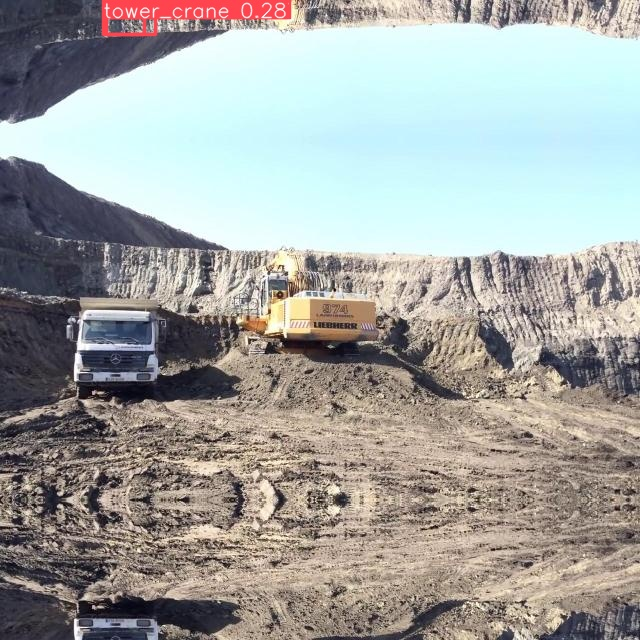


📸 image3.jpg


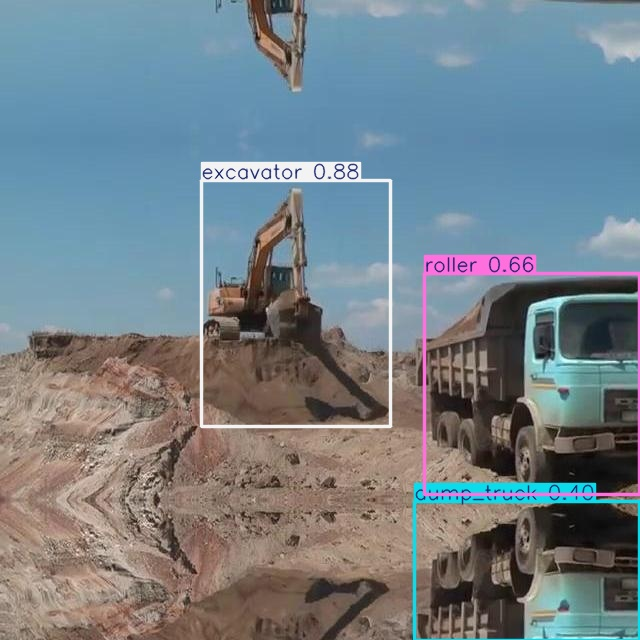


📸 image4.jpg


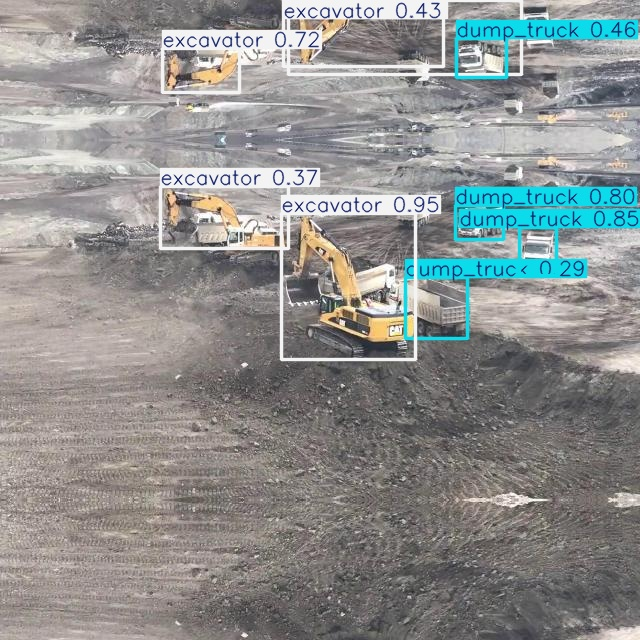


📸 image5.jpg


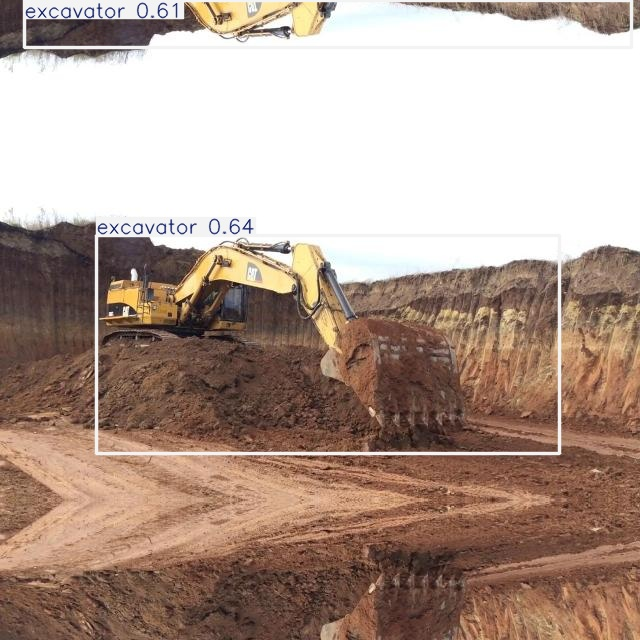


📸 image6.jpg


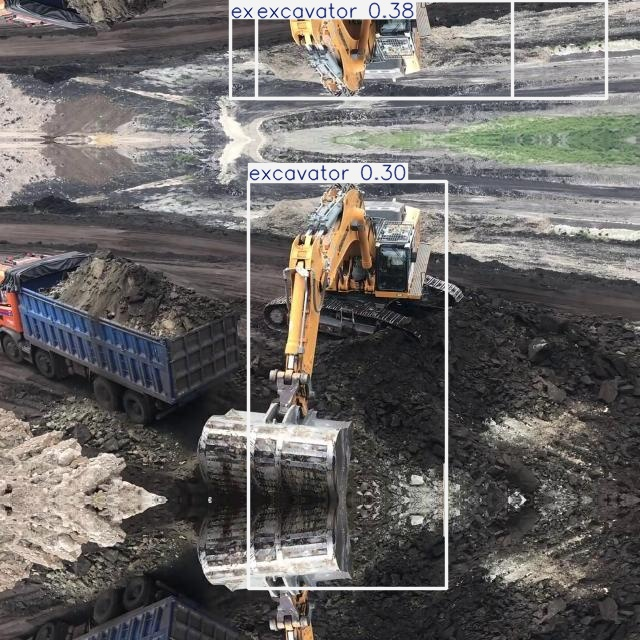


📸 image7.jpg


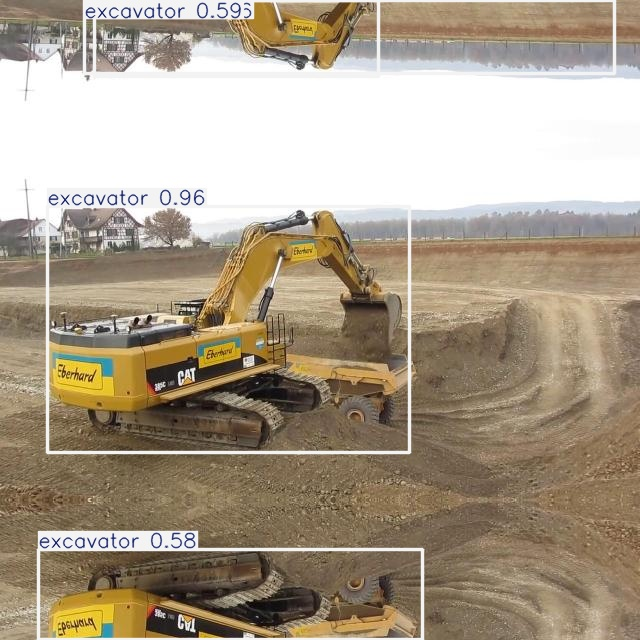


📸 image8.jpg


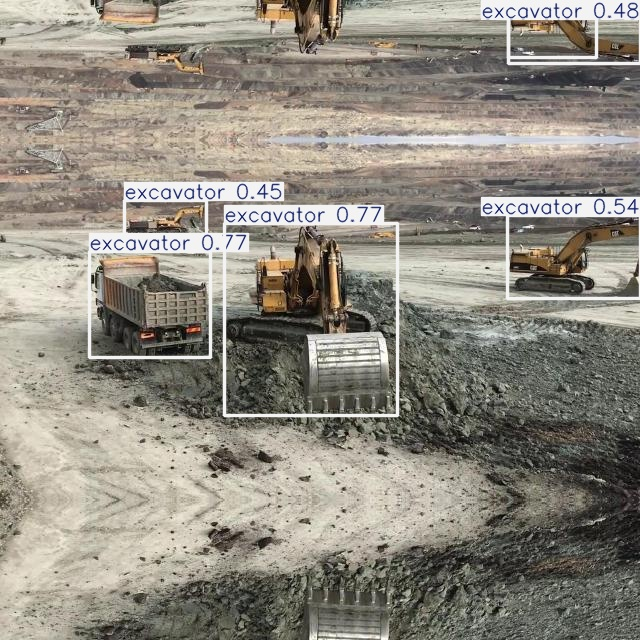


📸 image9.jpg


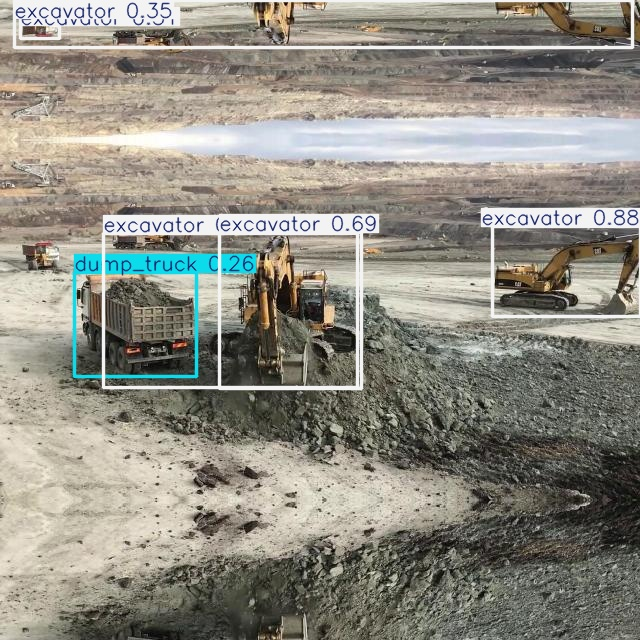



✅ Displayed 10 validation predictions.


In [ ]:
import glob
from IPython.display import display, Image

# Get 10 validation images
val_images = sorted(glob.glob('/content/dataset/valid/images/*'))[:10]
print(f"Running predictions on {len(val_images)} validation images...\n")

# Run inference
results = model.predict(
    source=val_images,
    save=True,
    conf=0.25,
    name='val_predictions'
)

# Display predictions
pred_dir = '/content/runs/detect/val_predictions/'
pred_images = sorted([f for f in os.listdir(pred_dir) if f.endswith(('.jpg', '.png'))])

for img_name in pred_images[:10]:
    img_path = os.path.join(pred_dir, img_name)
    print(f"📸 {img_name}")
    display(Image(filename=img_path, width=500))
    print()

print(f"\n✅ Displayed {len(pred_images[:10])} validation predictions.")

#  New Image Predictions (automated, no manual upload)

📥 Downloading new test images from GitHub...

  ✅ excavator_test.jpg
  ✅ tower_crane_test.jpg
  ✅ mixer_truck_test.jpg
  ✅ roller_test.jpg
  ✅ boom_lift_test.jpg

image 1/5 /content/new_test_images/boom_lift_test.jpg: 480x640 (no detections), 14.2ms
image 2/5 /content/new_test_images/excavator_test.jpg: 448x640 1 excavator, 9.6ms
image 3/5 /content/new_test_images/mixer_truck_test.jpg: 448x640 1 excavator, 10.2ms
image 4/5 /content/new_test_images/roller_test.jpg: 512x640 1 roller, 9.2ms
image 5/5 /content/new_test_images/tower_crane_test.jpg: 448x640 1 tower_crane, 13.5ms
Speed: 3.2ms preprocess, 11.3ms inference, 1.6ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/new_predictions3
📸 boom_lift_test.jpg


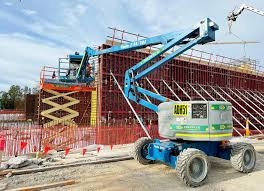


📸 excavator_test.jpg


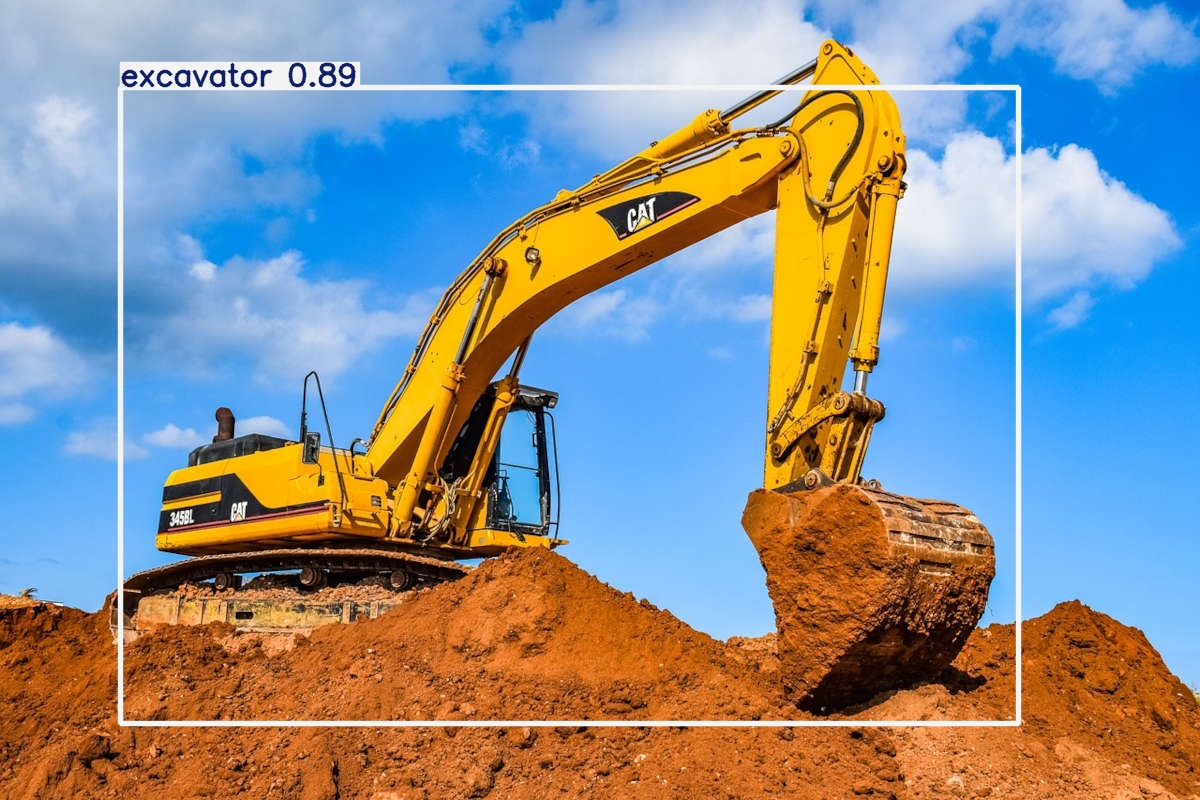


📸 mixer_truck_test.jpg


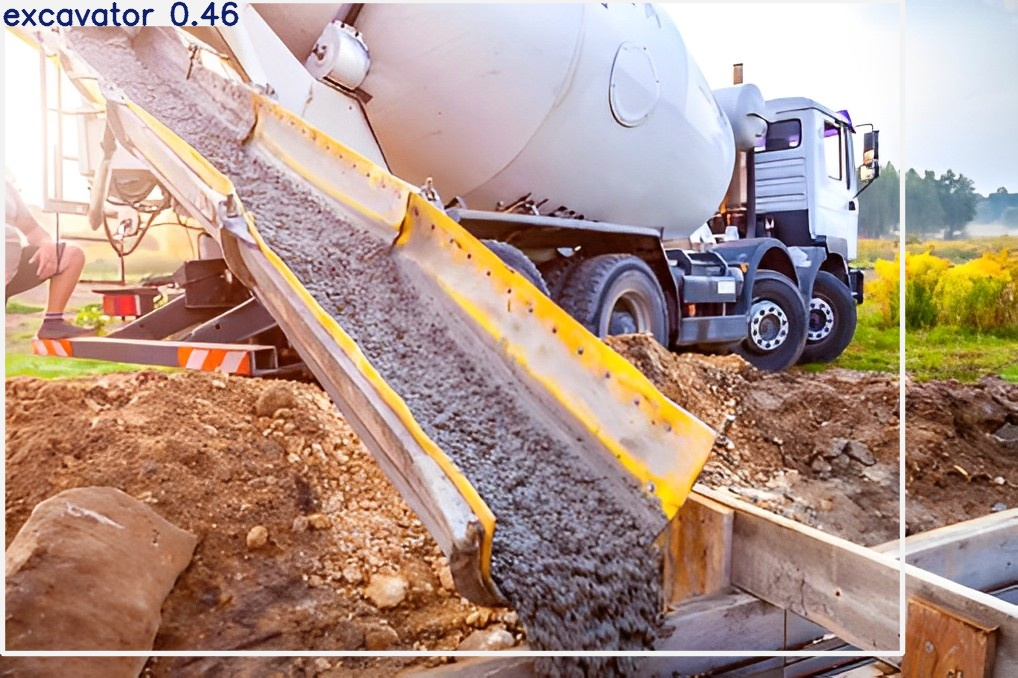


📸 roller_test.jpg


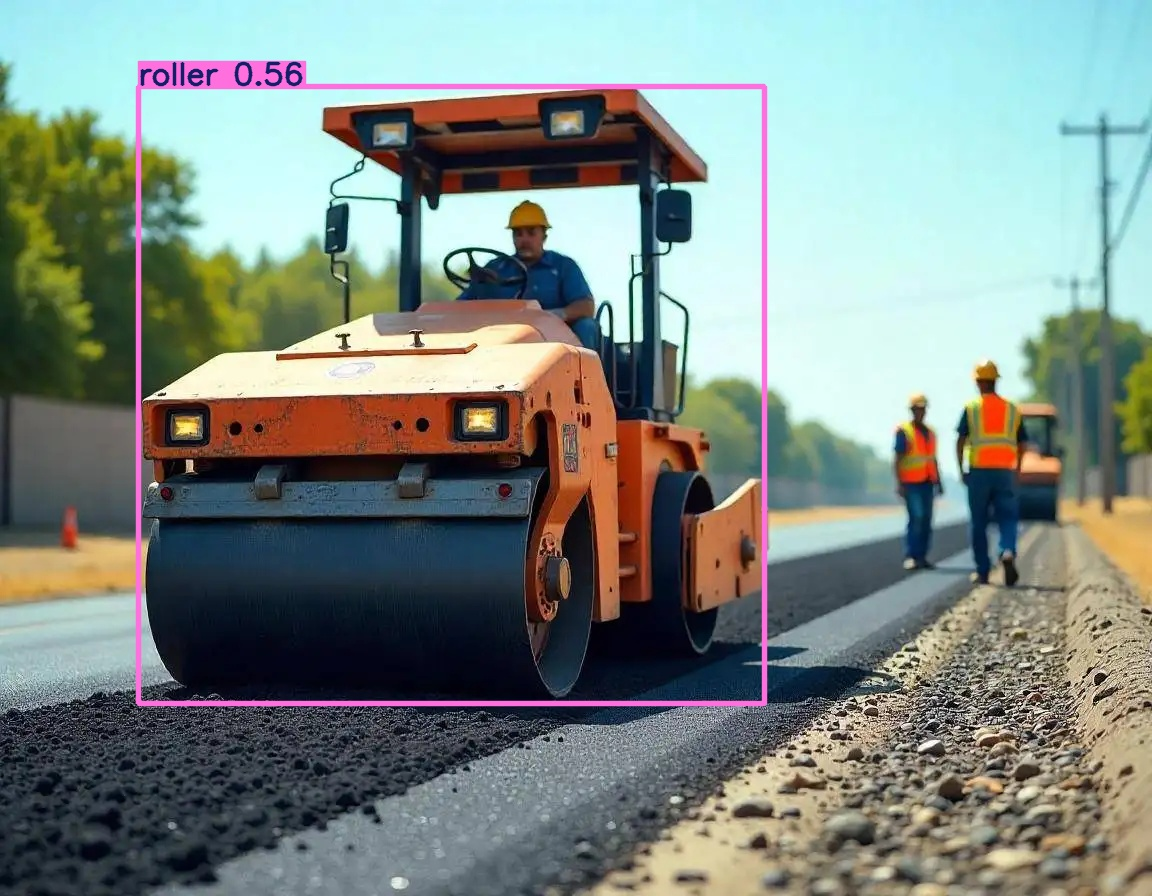


📸 tower_crane_test.jpg


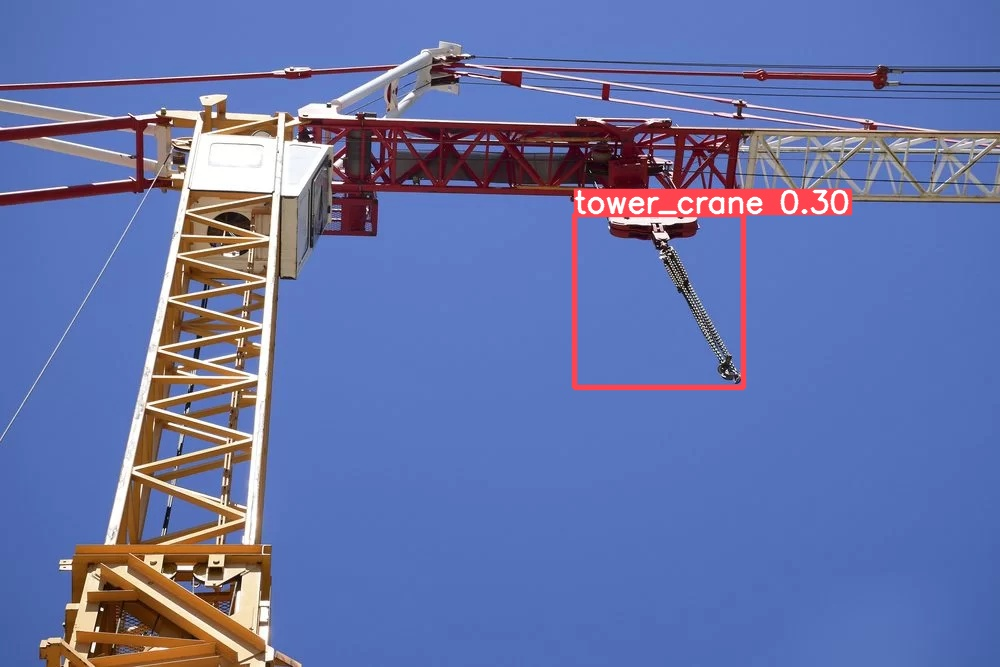



✅ 5 new image predictions complete.


In [ ]:
# ============================================================
# Download new test images from GitHub repo (no manual upload)
# ============================================================
import urllib.request
import os

new_img_dir = '/content/new_test_images/'
os.makedirs(new_img_dir, exist_ok=True)

# Base URL for raw files in your repo
base_url = "https://raw.githubusercontent.com/Vagiadim/SiteAI-equipment-tracker-/main/results/evidence/new_test_images/"

# List your 5 image filenames here
new_images = [
    "excavator_test.jpg",
    "tower_crane_test.jpg",
    "mixer_truck_test.jpg",
    "roller_test.jpg",
    "boom_lift_test.jpg"
]

print("📥 Downloading new test images from GitHub...\n")
for img_name in new_images:
    url = base_url + img_name
    save_path = os.path.join(new_img_dir, img_name)
    urllib.request.urlretrieve(url, save_path)
    print(f"  ✅ {img_name}")

# Run inference
results = model.predict(
    source=new_img_dir,
    save=True,
    conf=0.25,
    name='new_predictions'
)

# Display predictions
pred_dir = '/content/runs/detect/new_predictions/'
pred_images = sorted([f for f in os.listdir(pred_dir) if f.endswith(('.jpg', '.png'))])

for img_name in pred_images:
    img_path = os.path.join(pred_dir, img_name)
    print(f"📸 {img_name}")
    display(Image(filename=img_path, width=500))
    print()

print(f"\n✅ {len(pred_images)} new image predictions complete.")

# Download Weights (also automated)

In [ ]:
# ============================================================
# Load weights — from training run OR download from GitHub
# ============================================================
import os

best_weights = '/content/runs/detect/siteai_equipment/weights/best.pt'

# If weights don't exist (skipped training), download from GitHub
if not os.path.exists(best_weights):
    print("📥 Downloading pre-trained weights from GitHub Release...")
    os.makedirs(os.path.dirname(best_weights), exist_ok=True)
    !wget -q -O {best_weights} "https://github.com/Vagiadim/SiteAI-equipment-tracker-/releases/download/v1.0/best.pt"
    print("✅ Weights downloaded.")

model = YOLO(best_weights)

# Reproducibility Summary

In [ ]:
import datetime
import torch
import ultralytics

print("="*50)
print("    REPRODUCIBILITY SUMMARY")
print("="*50)
print(f"  Date/Time:         {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"  Ultralytics ver:   {ultralytics.__version__}")
print(f"  PyTorch ver:       {torch.__version__}")
print(f"  GPU:               {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print(f"  Model:             YOLOv8n")
print(f"  Dataset:           SiteAI-equipment-tracker v9 (Team7_Dataset_V1)")
print(f"  Split:             80/20 (train/val)")
print(f"  Epochs:            30")
print(f"  Image size:        640")
print(f"  Batch:             auto")
print(f"  Patience:          10 (early stopping)")
print("="*50)
print("\nCopy the above into your README reproducibility checklist.")

    REPRODUCIBILITY SUMMARY
  Date/Time:         2026-02-25 18:31:29
  Ultralytics ver:   8.4.16
  PyTorch ver:       2.10.0+cu128
  GPU:               Tesla T4
  Model:             YOLOv8n
  Dataset:           SiteAI-equipment-tracker v9 (Team7_Dataset_V1)
  Split:             80/20 (train/val)
  Epochs:            30
  Image size:        640
  Batch:             auto
  Patience:          10 (early stopping)

Copy the above into your README reproducibility checklist.
